# Gravitational Sonar v16 — JAX accelerated

Physics preserved from `Sonar_v16_GoldenRun16a`: same metric ansatz,
Hamiltonian, dissipation, RK4 rule, numerical-kludge waveform, Ricci
tensor, boundary condition, loss weights, initial conditions, and
Adam → BFGS/SSBroyden2 schedule.

Backend-only changes:

- one compiled loss/gradient with `jax.jit`
- RK4 time evolution with `jax.lax.scan`
- Ricci, boundary, observer, and diagnostic grids with `jax.vmap`
- quadrupole and polarization loops replaced by equivalent `einsum`
- network stored as a 69-scalar JAX pytree

**Colab:** choose a GPU runtime before running. First call for each
window/dtype compiles; time subsequent calls, not compilation.

## Setup

In [ ]:
# Colab already ships JAX. This only supplies the original custom BFGS patch.
!wget -q -nc https://raw.githubusercontent.com/EliKiani/Optimizing_the_Optimizer_PINNs/main/_optimize.py
!sed -i 's/^from \.\([a-zA-Z_]*\) import/from scipy.optimize.\1 import/' _optimize.py

In [ ]:
import math
import os
import time
from pathlib import Path

import jax
jax.config.update("jax_enable_x64", True)  # needed by the original BFGS handoff
import jax.numpy as jnp
from jax import lax, random, tree_util
from jax.flatten_util import ravel_pytree
import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize
from scipy.optimize import minimize

print("JAX:", jax.__version__)
print("Devices:", jax.devices())
if jax.default_backend() == "cpu":
    print("WARNING: CPU backend. In Colab select Runtime > Change runtime type > GPU.")

Array = jax.Array

JAX: 0.7.2
Devices: [CudaDevice(id=0)]


## Data and physical inputs

In [ ]:
DATA_DIR = Path("/content")
FILE_TAG = "Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1260_observertheta_0.7853981633974483"

t_true, hp_np = np.loadtxt(DATA_DIR / f"waveform_real_{FILE_TAG}.txt", unpack=True)
_, hc_np = np.loadtxt(DATA_DIR / f"waveform_imag_{FILE_TAG}.txt", unpack=True)
soln_true = np.loadtxt(DATA_DIR / f"solution_{FILE_TAG}.txt", unpack=True)

rp_true = 10.0
ra_true = 14.0
a_true = 0.9
theta_min_true = math.pi / 4
theta_observed = jnp.asarray([math.pi / 4], dtype=jnp.float32)

# Exact original grid: 1,000 coordinate-time samples over [0, 1260].
t_full = jnp.linspace(0.0, 1260.0, 1000, dtype=jnp.float32)
hp_full = jnp.asarray(hp_np[: len(t_full)], dtype=jnp.float32)[None, :]
hc_full = jnp.asarray(hc_np[: len(t_full)], dtype=jnp.float32)[None, :]

dt_np = np.diff(np.asarray(t_full))
assert np.allclose(dt_np, dt_np[0], rtol=1e-3), "t must be uniform"
print("samples:", len(t_full), "observers:", len(theta_observed))

samples: 1000 observers: 1


## 69-parameter metric network and unchanged ansatz

In [ ]:
def init_network(key, dtype=jnp.float32):
    # Same Linear(2,8) -> SiLU -> Linear(8,5) architecture: 69 scalars.
    k1, k2, k3, k4 = random.split(key, 4)
    l1 = 1.0 / math.sqrt(2.0)
    l2 = 1.0 / math.sqrt(8.0)
    return {
        "w1": random.uniform(k1, (8, 2), dtype, -l1, l1),
        "b1": random.uniform(k2, (8,), dtype, -l1, l1),
        "w2": random.uniform(k3, (5, 8), dtype, -l2, l2),
        "b2": random.uniform(k4, (5,), dtype, -l2, l2),
    }


def network_apply(params, x):
    hidden = jax.nn.silu(params["w1"] @ x + params["b1"])
    return params["w2"] @ hidden + params["b2"]


def nn_input(r, theta):
    return jnp.stack((1.0 / r, jnp.cos(theta) ** 2))


def Kerr(x, a, M=1.0):
    r, theta = x[1], x[2]
    delta = r**2 - 2.0 * M * r + a**2
    sigma = r**2 + a**2 * jnp.cos(theta) ** 2
    A = (r**2 + a**2) ** 2 - delta * a**2 * jnp.sin(theta) ** 2
    g_tt = -(1.0 - 2.0 * M * r / sigma)
    g_rr = sigma / delta
    g_thth = sigma
    g_phph = A / sigma * jnp.sin(theta) ** 2
    g_tph = (-2.0 * M * r / sigma) * a * jnp.sin(theta) ** 2
    z = jnp.zeros_like(r)
    return jnp.stack((
        jnp.stack((g_tt, z, z, g_tph)),
        jnp.stack((z, g_rr, z, z)),
        jnp.stack((z, z, g_thth, z)),
        jnp.stack((g_tph, z, z, g_phph)),
    ))


def g_Kerr(r, theta, M=1.0, a=a_true):
    return Kerr(jnp.stack((jnp.zeros_like(r), r, theta, jnp.zeros_like(r))), a, M)


def NN_Ansatz(r, theta, fields):
    u = 1.0 / r
    g_tt = -1.0 + u * fields[0]
    g_rr = 1.0 / (1.0 + u * fields[1])
    g_thth = r**2 + fields[2]
    g_phph = jnp.sin(theta) ** 2 * (r**2 + fields[3])
    g_tph = u * jnp.sin(theta) ** 2 * fields[4]
    z = jnp.zeros_like(r)
    return jnp.stack((
        jnp.stack((g_tt, z, z, g_tph)),
        jnp.stack((z, g_rr, z, z)),
        jnp.stack((z, z, g_thth, z)),
        jnp.stack((g_tph, z, z, g_phph)),
    ))


def metric_from_network(params, r, theta):
    return NN_Ansatz(r, theta, network_apply(params, nn_input(r, theta)))


params = init_network(random.PRNGKey(0))
flat0, _ = ravel_pytree(params)
assert flat0.size == 69
print("parameters:", flat0.size, "test output:", network_apply(params, jnp.array([2.0, 1.57])))

parameters: 69 test output: [-0.61378847  0.65292454  0.55026903 -0.2847634  -0.58163525]


In [ ]:
R_LO, R_HI = 6.2, 20.0
TH_LO, TH_HI = 0.1, math.pi/2 - 0.1

def logit(x):
    x = jnp.clip(x, 1e-6, 1 - 1e-6)
    return jnp.log(x) - jnp.log1p(-x)

def inv_softplus(x):
    return jnp.log(jnp.expm1(x))

def encode_ic(r, theta, pt, Lz):
    return jnp.asarray([
        logit((r - R_LO) / (R_HI - R_LO)),
        logit((theta - TH_LO) / (TH_HI - TH_LO)),
        inv_softplus(-pt),
        inv_softplus(Lz),
    ], dtype=jnp.float32)

def decode_ic(z):
    r = R_LO + (R_HI - R_LO) * jax.nn.sigmoid(z[0])
    theta = TH_LO + (TH_HI - TH_LO) * jax.nn.sigmoid(z[1])
    pt = -jax.nn.softplus(z[2])
    Lz = jax.nn.softplus(z[3])
    return jnp.asarray([0., r, theta, 0., pt, 0., 0., Lz])

params = {
    "metric": params,
    "ic": encode_ic(9.0, 0.90, -0.90, 2.30),
}

assert ravel_pytree(params)[0].size == 73

## Initial conditions — unchanged Kerr map, evaluated once outside JIT

In [ ]:
def solve_ELQ(r_p, r_a, theta_min, M=1.0, a=a_true, mu=1.0):
    delta_p = r_p**2 - 2.0 * M * r_p + a**2
    delta_a = r_a**2 - 2.0 * M * r_a + a**2

    def equations(v):
        E, Lz = v
        Qp = (((r_p**2 + a**2) * E - a * Lz) ** 2
              - delta_p * ((Lz - a * E) ** 2 + mu**2 * r_p**2)) / delta_p
        F0 = (((r_a**2 + a**2) * E - a * Lz) ** 2
              - delta_a * ((Lz - a * E) ** 2 + mu**2 * r_a**2 + Qp))
        F1 = Qp - math.cos(theta_min) ** 2 * (
            a**2 * (mu**2 - E**2) + Lz**2 / math.sin(theta_min) ** 2
        )
        return (F0, F1)

    E0 = math.sqrt(1.0 - 2.0 * M / (r_p + r_a))
    L0 = math.sqrt(M * (r_p + r_a) / 2.0)
    E, Lz = optimize.fsolve(equations, (E0, L0))
    Q = ((((r_p**2 + a**2) * E - a * Lz) ** 2
         - delta_p * ((Lz - a * E) ** 2 + mu**2 * r_p**2)) / delta_p)
    return E, Lz, Q


def make_u0(r_p, r_a, theta_min, M=1.0, a=a_true, mu=1.0):
    E, Lz, _ = solve_ELQ(r_p, r_a, theta_min, M, a, mu)
    return np.asarray([0.0, r_p, theta_min, 0.0, -E, 0.0, 0.0, Lz])


# solve_ELQ is not part of training AD: original ICs are fixed.
U0 = jnp.asarray(make_u0(rp_true, ra_true, theta_min_true), dtype=jnp.float64)
print("u0:", U0)

u0: [ 0.         10.          0.78539816  0.         -0.96048519  0.
  0.          2.66185247]


## Hamiltonian and RK4 — same equations, `lax.scan` time loop

In [ ]:
I4 = jnp.eye(4)
Z4 = jnp.zeros((4, 4))
SYMPLECTIC = jnp.block([[Z4, I4], [-I4, Z4]])
DISSIPATION = -10e-4 * jnp.asarray([0, 0, 0, 0, 0, 0, 0, 1])


def hamiltonian_network(params, state):
    _, r, theta, _, p_t, p_r, p_theta, p_phi = state
    inv_g = jnp.linalg.inv(metric_from_network(params, r, theta))
    p = jnp.stack((p_t, p_r, p_theta, p_phi))
    return 0.5 * p @ inv_g @ p


def H_function(params, state):
    grad_H = jax.grad(hamiltonian_network, argnums=1)(params, state)
    du_dtau = SYMPLECTIC.astype(state.dtype) @ grad_H + DISSIPATION.astype(state.dtype)
    du = du_dtau / grad_H[4]
    return du.at[0].set(1.0)


def hamiltonian_kerr(state):
    inv_g = jnp.linalg.inv(Kerr(state[:4], a_true))
    return 0.5 * state[4:] @ inv_g @ state[4:]


def H_Kerr(state):
    grad_H = jax.grad(hamiltonian_kerr)(state)
    du_dtau = SYMPLECTIC.astype(state.dtype) @ grad_H + DISSIPATION.astype(state.dtype)
    du = du_dtau / grad_H[4]
    return du.at[0].set(1.0)


def rk4_step(rhs, time, state, step):
    k1 = rhs(time, state)
    k2 = rhs(time + step / 2.0, state + step * k1 / 2.0)
    k3 = rhs(time + step / 2.0, state + step * k2 / 2.0)
    k4 = rhs(time + step, state + step * k3)
    return state + step * (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0


def integrate(rhs, y0, t_array):
    step = t_array[1] - t_array[0]

    def scan_step(state, time):
        next_state = rk4_step(rhs, time, state, step)
        return next_state, next_state

    _, tail = lax.scan(scan_step, y0, t_array[:-1])
    return jnp.concatenate((y0[None, :], tail), axis=0)


def integrate_network(params, y0, t_array):
    return integrate(lambda time, state: H_function(params, state), y0, t_array)


def integrate_kerr(y0, t_array):
    return integrate(lambda time, state: H_Kerr(state), y0, t_array)

## Numerical-kludge waveform — identical algebra, vectorized

In [ ]:
def d2_dt2(v, dt):
    first = 2.0 * v[..., 0] - 5.0 * v[..., 1] + 4.0 * v[..., 2] - v[..., 3]
    middle = v[..., :-2] - 2.0 * v[..., 1:-1] + v[..., 2:]
    last = 2.0 * v[..., -1] - 5.0 * v[..., -2] + 4.0 * v[..., -3] - v[..., -4]
    return jnp.concatenate((first[..., None], middle, last[..., None]), axis=-1) / dt**2


def Soln2Orbit(soln, a):
    r, theta, phi = soln[:, 1], soln[:, 2], soln[:, 3]
    return jnp.stack((
        r * jnp.sin(theta) * jnp.cos(phi),
        r * jnp.sin(theta) * jnp.sin(phi),
        r * jnp.cos(theta),
    ))


def Q_ij(orbit, mu=1.0):
    outer = jnp.einsum("in,jn->ijn", orbit, orbit)
    r2 = jnp.sum(orbit**2, axis=0)
    return mu * (outer - jnp.eye(3, dtype=orbit.dtype)[:, :, None] * r2[None, None, :] / 3.0)


def Observer_Basis(theta_obs, phi_obs):
    n = jnp.stack((jnp.sin(theta_obs) * jnp.cos(phi_obs),
                   jnp.sin(theta_obs) * jnp.sin(phi_obs),
                   jnp.cos(theta_obs)))
    p = jnp.stack((jnp.cos(theta_obs) * jnp.cos(phi_obs),
                   jnp.cos(theta_obs) * jnp.sin(phi_obs),
                  -jnp.sin(theta_obs)))
    q = jnp.stack((-jnp.sin(phi_obs), jnp.cos(phi_obs), jnp.zeros_like(phi_obs)))
    return n, p, q


def project_waveform(Qdd, theta_obs=0.0, phi_obs=0.0, D=1.0):
    _, p, q = Observer_Basis(theta_obs, phi_obs)
    e_plus = jnp.einsum("i,j->ij", p, p) - jnp.einsum("i,j->ij", q, q)
    e_cross = jnp.einsum("i,j->ij", p, q) + jnp.einsum("i,j->ij", q, p)
    return (jnp.einsum("ij,ijn->n", e_plus, Qdd) / D,
            jnp.einsum("ij,ijn->n", e_cross, Qdd) / D)


def create_gravityWave(t_array, soln, a, mu=1.0, theta_obs=0.0, phi_obs=0.0, D=1.0):
    orbit = Soln2Orbit(soln, a)
    Qdd = d2_dt2(Q_ij(orbit, mu), t_array[1] - t_array[0])
    return project_waveform(Qdd, theta_obs, phi_obs, D)

## Curvature and boundary terms — full-grid `vmap`

In [ ]:
def christ_awful(metric, x):
    partial_g = jax.jacfwd(metric)(x)
    ginv = jnp.linalg.inv(metric(x))
    term1 = jnp.einsum("ms,sab->mab", ginv, partial_g)
    term2 = jnp.einsum("ms,sba->mab", ginv, partial_g)
    term3 = jnp.einsum("ms,abs->mab", ginv, partial_g)
    return 0.5 * (term1 + term2 - term3)


def Riemann(metric, x):
    dGamma = jax.jacfwd(lambda y: christ_awful(metric, y))(x)
    Gamma = christ_awful(metric, x)  # one evaluation; original recomputed it four times
    term1 = jnp.einsum("abvu->abuv", dGamma)
    term2 = jnp.einsum("abuv->abuv", dGamma)
    term3 = jnp.einsum("aup,pbv->abuv", Gamma, Gamma)
    term4 = jnp.einsum("avp,pbu->abuv", Gamma, Gamma)
    return term1 - term2 + term3 - term4


def Ricci(metric, x):
    return jnp.einsum("abav->bv", Riemann(metric, x))


R_INNER = jnp.logspace(math.log10(2.0), math.log10(20.0), 20)
R_OUTER = jnp.asarray([30.0, 50.0, 100.0, 200.0])
THETA_RICCI = jnp.linspace(math.pi / 20.0, math.pi / 2.0, 4)
RR, TT = jnp.meshgrid(jnp.concatenate((R_INNER, R_OUTER)), THETA_RICCI, indexing="ij")
RICCI_POINTS = jnp.stack((jnp.zeros(RR.size), RR.ravel(), TT.ravel(), jnp.zeros(RR.size)), axis=1)
BC_R = jnp.linspace(1.0, 2.01, 80)
BC_THETA = jnp.linspace(0.0, math.pi / 2.0, 4)


def ricci_loss(params):
    metric = lambda x: metric_from_network(params, x[1], x[2])
    points = RICCI_POINTS.astype(params["w1"].dtype)
    values = jax.vmap(lambda x: Ricci(metric, x))(points)
    return jnp.mean(jnp.sum(values**2, axis=(1, 2)))


def boundaryConditionLoss(params):
    dtype = params["w1"].dtype
    r_vals = BC_R.astype(dtype)
    theta_vals = BC_THETA.astype(dtype)
    tau = jnp.asarray(1e-4, dtype=dtype)

    def one_theta(theta):
        points = jnp.stack((jnp.zeros_like(r_vals), r_vals,
                            jnp.full_like(r_vals, theta), jnp.zeros_like(r_vals)), axis=1)
        residuals = jax.vmap(
            lambda x: 1.0 / metric_from_network(params, x[1], x[2])[1, 1]
        )(points)
        weights = jax.nn.softmax(-(residuals**2) / tau)
        root = jnp.sum(weights * r_vals)
        root_residual = 1.0 / metric_from_network(params, root, theta)[1, 1]
        sign_penalty = jax.nn.relu(residuals[0] * residuals[-1])
        return root, root_residual**2, sign_penalty

    roots, root_residuals, sign_penalties = jax.vmap(one_theta)(theta_vals)
    # torch.var default used correction=1; preserve that convention.
    location_consistency = jnp.var(roots, ddof=1)
    total = location_consistency + jnp.mean(root_residuals) + jnp.mean(sign_penalties)
    return total, roots

## Loss — one compiled value/gradient

In [ ]:
def mass_shell_loss(metric_params, u0):
    g = metric_from_network(metric_params, u0[1], u0[2])
    p = u0[4:]
    return (p @ jnp.linalg.inv(g) @ p + 1.0)**2


def hann_periodic(N, dtype):
    n = jnp.arange(N, dtype=dtype)
    return 0.5 * (1.0 - jnp.cos(2.0 * jnp.pi * n / N))


def SpectralLoss(h_true, h_pred):
    window = hann_periodic(h_true.shape[0], h_true.real.dtype)
    true_mag = jnp.abs(jnp.fft.fft(window * h_true))
    pred_mag = jnp.abs(jnp.fft.fft(window * h_pred))
    eps = 1e-4 * jnp.mean(true_mag**2)
    return jnp.mean((true_mag - pred_mag) ** 2 / (true_mag**2 + eps))

def waveform_loss(metric_params, u0, t_array, hp_true, hc_true, eps=1e-12):
    trajectory = integrate_network(metric_params, u0, t_array)
    observers = theta_observed.astype(metric_params["w1"].dtype)

    hp_pred, hc_pred = jax.vmap(
        lambda theta: create_gravityWave(
            t_array, trajectory, a_true, theta_obs=theta
        )
    )(observers)

    squared_error = jnp.mean(
        (hp_pred - hp_true)**2 + (hc_pred - hc_true)**2,
        axis=1,
    )
    truth_power = lax.stop_gradient(
        jnp.mean(hp_true**2 + hc_true**2, axis=1)
    )

    return (
        jnp.mean(squared_error / (truth_power + eps)),
        hp_pred,
        hc_pred,
    )


LOSS_WEIGHTS = jnp.asarray([1.0, 0.5, 0.1, 0.1])
P_MASS_SHELL = 10.0

def ricci_residual_vector(metric_params):
    metric = lambda x: metric_from_network(
        metric_params, x[1], x[2]
    )

    points = RICCI_POINTS.astype(metric_params["w1"].dtype)
    values = jax.vmap(lambda x: Ricci(metric, x))(points)

    # Existing loss:
    # mean(sum(R**2, axis=(1, 2)))
    return values.reshape(-1) / jnp.sqrt(values.shape[0])


def boundary_residual_vector(metric_params):
    dtype = metric_params["w1"].dtype
    r_vals = BC_R.astype(dtype)
    theta_vals = BC_THETA.astype(dtype)
    tau = jnp.asarray(1e-4, dtype=dtype)

    def one_theta(theta):
        points = jnp.stack((
            jnp.zeros_like(r_vals),
            r_vals,
            jnp.full_like(r_vals, theta),
            jnp.zeros_like(r_vals),
        ), axis=1)

        q = jax.vmap(
            lambda x:
                1.0 / metric_from_network(
                    metric_params, x[1], x[2]
                )[1, 1]
        )(points)

        soft_weights = jax.nn.softmax(-(q**2) / tau)
        root = jnp.sum(soft_weights * r_vals)

        q_root = (
            1.0
            / metric_from_network(
                metric_params, root, theta
            )[1, 1]
        )

        sign_penalty = jax.nn.relu(q[0] * q[-1])
        return root, q_root, sign_penalty

    roots, q_roots, sign_penalties = jax.vmap(one_theta)(
        theta_vals
    )

    n = roots.size

    # Sum of squares equals existing boundary loss.
    spread = (
        (roots - jnp.mean(roots))
        / jnp.sqrt(jnp.asarray(n - 1, dtype=dtype))
    )

    root_zero = (
        q_roots
        / jnp.sqrt(jnp.asarray(n, dtype=dtype))
    )

    # Existing sign term is not squared.
    # sqrt converts it into a least-squares residual.
    sign = (
        jnp.sqrt(
            sign_penalties
            + jnp.asarray(1e-30, dtype=dtype)
        )
        / jnp.sqrt(jnp.asarray(n, dtype=dtype))
    )

    return jnp.concatenate((spread, root_zero, sign))


def full_residual_vector(
    joint,
    t_array,
    hp_true,
    hc_true,
    weights,
):
    metric_params = joint["metric"]
    u0 = decode_ic(joint["ic"])
    dtype = metric_params["w1"].dtype
    weights = weights.astype(dtype)

    # Integrate only once.
    trajectory = integrate_network(
        metric_params, u0, t_array
    )

    hp_pred, hc_pred = jax.vmap(
        lambda theta: create_gravityWave(
            t_array,
            trajectory,
            a_true,
            theta_obs=theta,
        )
    )(theta_observed.astype(dtype))

    # Waveform residual: exactly reproduces waveform_loss.
    truth_power = lax.stop_gradient(
        jnp.mean(
            hp_true**2 + hc_true**2,
            axis=1,
        )
    )

    n_obs, n_time = hp_pred.shape

    wave_denominator = jnp.sqrt(
        (truth_power + 1e-12)[:, None]
        * jnp.asarray(n_obs * n_time, dtype=dtype)
    )

    wave_residual = jnp.concatenate((
        ((hp_pred - hp_true) / wave_denominator).reshape(-1),
        ((hc_pred - hc_true) / wave_denominator).reshape(-1),
    ))

    # Frequency residual: exactly reproduces SpectralLoss.
    window = hann_periodic(n_time, dtype)

    true_complex = hp_true[0] + 1j * hc_true[0]
    pred_complex = hp_pred[0] + 1j * hc_pred[0]

    true_mag = jnp.abs(jnp.fft.fft(window * true_complex))
    pred_mag = jnp.abs(jnp.fft.fft(window * pred_complex))

    spectral_eps = 1e-4 * jnp.mean(true_mag**2)

    frequency_residual = (
        (pred_mag - true_mag)
        / jnp.sqrt(
            (true_mag**2 + spectral_eps)
            * jnp.asarray(true_mag.size, dtype=dtype)
        )
    )

    ricci_residual = ricci_residual_vector(metric_params)
    boundary_residual = boundary_residual_vector(metric_params)

    # Unsquared mass-shell constraint.
    g0 = metric_from_network(
        metric_params, u0[1], u0[2]
    )
    p0 = u0[4:]

    shell_residual = jnp.asarray([
        p0 @ jnp.linalg.inv(g0) @ p0 + 1.0
    ])

    # sqrt(weights), because the optimizer squares these.
    return jnp.concatenate((
        jnp.sqrt(weights[0]) * wave_residual,
        jnp.sqrt(weights[1]) * ricci_residual,
        jnp.sqrt(weights[2]) * frequency_residual,
        jnp.sqrt(weights[3]) * boundary_residual,
        jnp.sqrt(
            jnp.asarray(P_MASS_SHELL, dtype=dtype)
        ) * shell_residual,
    ))

def loss(joint, t_array, hp_true, hc_true, weights):
    metric_params = joint["metric"]
    u0 = decode_ic(joint["ic"])

    waveformLoss, hp_pred, hc_pred = waveform_loss(
        metric_params, u0, t_array, hp_true, hc_true
    )
    ricciLoss = ricci_loss(metric_params)
    boundaryLoss, roots = boundaryConditionLoss(metric_params)
    frequencyLoss = SpectralLoss(
        hp_true[0] + 1j * hc_true[0],
        hp_pred[0] + 1j * hc_pred[0],
    )
    shellLoss = mass_shell_loss(metric_params, u0)

    components = jnp.stack((
        waveformLoss,
        ricciLoss,
        frequencyLoss,
        boundaryLoss,
    ))

    total = (
        jnp.dot(weights.astype(components.dtype), components)
        + P_MASS_SHELL * shellLoss
    )

    return total, (components, roots, shellLoss, u0)


loss_value_and_grad = jax.jit(
    jax.value_and_grad(loss, argnums=0, has_aux=True)
)
loss_only = jax.jit(loss)

## Physics gates

In [ ]:
@jax.jit
def exact_kerr_gate(t_array):
    trajectory = integrate_kerr(U0.astype(t_array.dtype), t_array)
    return trajectory, create_gravityWave(
        t_array, trajectory, a_true, theta_obs=theta_observed[0].astype(t_array.dtype)
    )


trajectory_gate, (hp_gate, hc_gate) = exact_kerr_gate(t_full)
relative_L2 = 100.0 * jnp.linalg.norm((hp_gate + 1j * hc_gate) - (hp_full[0] + 1j * hc_full[0])) / (
    jnp.linalg.norm(hp_full[0] + 1j * hc_full[0]) + 1e-12
)
print("Exact-Kerr waveform L2 error (%):", float(relative_L2))

x_gate = jnp.asarray([0.0, 10.0, math.pi / 2.0, 0.0], dtype=jnp.float64)
print("Kerr Ricci gate:\n", Ricci(lambda x: Kerr(x, a_true), x_gate))
assert np.isfinite(np.asarray(relative_L2))

Exact-Kerr waveform L2 error (%): 0.3517760932445526
Kerr Ricci gate:
 [[ 2.16840434e-19  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  6.93889390e-18 -1.03518735e-33  0.00000000e+00]
 [ 0.00000000e+00 -3.55093333e-33  5.55111512e-17  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  9.43689571e-16]]


In [ ]:
# Matched-forward control: train on waveform generated by this JAX forward model
hp_full = hp_gate[None, :]
hc_full = hc_gate[None, :]

print("MATCHED-FORWARD TARGET ENABLED")

MATCHED-FORWARD TARGET ENABLED


## Checkpoints

In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    SAVE_DIR = Path("/content/drive/MyDrive")
except ImportError:
    SAVE_DIR = Path(".")

RUN_ID = "joint_ic_metric_matched_forward_seed0_long"
RESUME = False

CHECKPOINT_PATH = SAVE_DIR / f"{RUN_ID}_live.npz"
FINAL_PATH = SAVE_DIR / f"{RUN_ID}_final.npz"

def save_checkpoint(path, params, stage_idx, epoch, n, histories):
    flat, _ = ravel_pytree(params)
    np.savez(
        path,
        flat_params=np.asarray(jax.device_get(flat)),
        stage_idx=stage_idx,
        epoch=epoch,
        n=n,
        **{name: np.asarray(values) for name, values in histories.items()},
    )


def load_checkpoint(path, template):
    if not Path(path).exists():
        return None
    data = np.load(path)
    _, unravel = ravel_pytree(template)
    loaded = unravel(jnp.asarray(data["flat_params"]))
    names = (
        "total", "waveform", "ricci",
        "frequency", "boundary", "mass_shell",
        "monitor_ic", "monitor_metric",
    )
    histories = {
        name: data[name].tolist() if name in data else []
        for name in names
    }
    return loaded, int(data["stage_idx"]), int(data["epoch"]), int(data["n"]), histories


def import_pytorch_checkpoint(path):
    '''Optional one-time import of the original .pt network weights.'''
    import torch
    payload = torch.load(path, map_location="cpu")
    state = payload.get("net_state", payload)
    return {
        "w1": jnp.asarray(state["fc1.weight"].detach().numpy()),
        "b1": jnp.asarray(state["fc1.bias"].detach().numpy()),
        "w2": jnp.asarray(state["fc2.weight"].detach().numpy()),
        "b2": jnp.asarray(state["fc2.bias"].detach().numpy()),
    }

# To continue from a trained PyTorch model, uncomment before training:
# params = import_pytorch_checkpoint("/content/drive/MyDrive/sonar_v16_final.pt")

Mounted at /content/drive


## Adam — same curriculum, JIT loss/gradient

In [ ]:
def tree_zeros_like(tree):
    return tree_util.tree_map(jnp.zeros_like, tree)


def global_norm(tree):
    return jnp.sqrt(sum(jnp.vdot(x, x).real for x in tree_util.tree_leaves(tree)))


@jax.jit
def adam_update(params, grads, state, learning_rate):
    count, m, v = state
    count = count + 1
    grad_norm = global_norm(grads)
    scale = jnp.minimum(1.0, 1.0 / (grad_norm + 1e-12))
    grads = tree_util.tree_map(lambda g: g * scale, grads)
    m = tree_util.tree_map(lambda old, g: 0.9 * old + 0.1 * g, m, grads)
    v = tree_util.tree_map(lambda old, g: 0.999 * old + 0.001 * g * g, v, grads)
    mhat = tree_util.tree_map(lambda x: x / (1.0 - 0.9**count), m)
    vhat = tree_util.tree_map(lambda x: x / (1.0 - 0.999**count), v)
    params = tree_util.tree_map(
        lambda p, mm, vv: p - learning_rate * mm / (jnp.sqrt(vv) + 1e-8),
        params, mhat, vhat,
    )
    return params, (count, m, v), grad_norm


def metric_errors(params):
    metric_params = params["metric"]

    radii = jnp.asarray(
        [2, 3, 4, 5, 6, 12, 20],
        dtype=metric_params["w1"].dtype,
    )
    angles = jnp.asarray(
        [math.pi / 20, math.pi / 4, math.pi / 3, math.pi / 2],
        dtype=metric_params["w1"].dtype,
    )

    def errors_at_r(r):
        pred = jax.vmap(
            lambda th: metric_from_network(metric_params, r, th)
        )(angles)

        true = jax.vmap(
            lambda th: g_Kerr(r, th)
        )(angles)

        ij = jnp.asarray([
            [0, 0],
            [1, 1],
            [2, 2],
            [3, 3],
            [0, 3],
        ])

        return jax.vmap(
            lambda pair:
                100.0
                * jnp.linalg.norm(
                    pred[:, pair[0], pair[1]]
                    - true[:, pair[0], pair[1]]
                )
                / (
                    jnp.linalg.norm(
                        true[:, pair[0], pair[1]]
                    )
                    + 1e-12
                )
        )(ij)

    return jax.vmap(errors_at_r)(radii).T


metric_errors_jit = jax.jit(metric_errors)

histories = {name: [] for name in (
    "total", "waveform", "ricci",
    "frequency", "boundary", "mass_shell",
    "monitor_ic", "monitor_metric",
)}

def record_monitor(current_params):
    u = np.asarray(
        jax.device_get(decode_ic(current_params["ic"])),
        dtype=float,
    )

    # Mean error for each metric component over r >= 3.
    metric_error = np.asarray(
        jax.device_get(metric_errors_jit(current_params)),
        dtype=float,
    )[:, 1:].mean(axis=1)

    histories["monitor_ic"].append([
        u[1],       # r
        u[2],       # theta
        -u[4],      # E
        u[7],       # Lz
    ])
    histories["monitor_metric"].append(metric_error)

schedule = [(25, 45), (50, 40), (100, 35)]  # exact original warm-up
n = 0
start_stage_idx = 0
start_epoch = 0

if RESUME:
    restored = load_checkpoint(CHECKPOINT_PATH, params)
    if restored is not None:
        params, start_stage_idx, saved_epoch, n, histories = restored
        start_epoch = saved_epoch + 1
        print("resumed:", start_stage_idx, start_epoch, n)

if not histories["monitor_ic"]:
    record_monitor(params)

adam_state = (jnp.asarray(0), tree_zeros_like(params), tree_zeros_like(params))
start_time = time.time()
LOG_EVERY = 10  # logging only; physics/loss unchanged

for stage_idx, (window, epochs) in enumerate(schedule):
    if stage_idx < start_stage_idx:
        continue
    t_window = t_full[:window]
    hp_window = hp_full[:, :window]
    hc_window = hc_full[:, :window]
    epoch0 = start_epoch if stage_idx == start_stage_idx else 0
    learning_rate = jnp.asarray(1e-2, dtype=params["metric"]["w1"].dtype)
    print(f"\nAdam {stage_idx + 1}/{len(schedule)}: [0:{window}], {epochs} iterations")

    for epoch in range(epoch0, epochs):
        (value_aux, grads) = loss_value_and_grad(
            params, t_window, hp_window, hc_window, LOSS_WEIGHTS
        )
        total, (components, roots, shell, u0_fit) = value_aux
        params, adam_state, grad_norm = adam_update(params, grads, adam_state, learning_rate)
        total.block_until_ready()

        if (n + 1) % 10 == 0:
          print(
              f"r0={float(u0_fit[1]):.6f}  "
              f"theta0={float(u0_fit[2]):.6f}  "
              f"E0={float(-u0_fit[4]):.6f}  "
              f"Lz0={float(u0_fit[7]):.6f}  "
              f"shell={float(shell):.3e}"
          )

        values = np.asarray(jax.device_get(components))
        histories["total"].append(float(total))
        for name, value, weight in zip(
            ("waveform", "ricci", "frequency", "boundary"), values, np.asarray(LOSS_WEIGHTS)
        ):
            histories[name].append(float(weight * value))
        histories["mass_shell"].append(
            float(P_MASS_SHELL * shell)
        )
        n += 1
        if n == 1 or n % LOG_EVERY == 0:
            record_monitor(params)
            elapsed = time.time() - start_time
            print(f"iter={n:4d} time={elapsed:7.1f}s total={float(total):.3e} "
                  f"W={values[0]:.2e} R={values[1]:.2e} F={values[2]:.2e} "
                  f"BC={values[3]:.2e} r_H={float(jnp.mean(roots)):.4f} |g|={float(grad_norm):.2e}")
        if n % 10 == 0:
            save_checkpoint(CHECKPOINT_PATH, params, stage_idx, epoch, n, histories)

    save_checkpoint(CHECKPOINT_PATH, params, stage_idx, epochs - 1, n, histories)

print("Adam complete:", n, "iterations")


Adam 1/3: [0:25], 45 iterations
iter=   1 time=   25.7s total=3.949e+00 W=2.49e+00 R=2.18e-02 F=4.63e-01 BC=2.98e+00 r_H=2.0100 |g|=1.68e+01
r0=9.204384  theta0=0.929401  E0=0.954460  Lz0=2.219931  shell=3.713e-02
iter=  10 time=   26.2s total=1.510e+00 W=8.85e-01 R=2.84e-03 F=3.47e-01 BC=2.17e+00 r_H=2.0100 |g|=7.81e+00
r0=9.428261  theta0=0.959142  E0=1.017487  Lz0=2.135533  shell=6.214e-04
iter=  20 time=   27.9s total=5.049e-01 W=3.44e-01 R=8.16e-04 F=2.64e-01 BC=1.28e+00 r_H=1.0000 |g|=1.29e+00
r0=9.567100  theta0=0.978204  E0=1.044380  Lz0=2.077441  shell=4.945e-03
iter=  30 time=   28.2s total=3.773e-01 W=2.71e-01 R=1.95e-03 F=2.10e-01 BC=3.49e-01 r_H=1.0000 |g|=2.22e+00
r0=9.528713  theta0=0.976253  E0=1.007641  Lz0=2.083005  shell=7.837e-06
iter=  40 time=   28.4s total=2.669e-01 W=2.46e-01 R=6.57e-03 F=1.78e-01 BC=2.34e-03 r_H=1.0646 |g|=3.48e-01

Adam 2/3: [0:50], 40 iterations
r0=9.401662  theta0=0.964437  E0=0.988563  Lz0=2.101417  shell=2.029e-04
iter=  50 time=   54.3s 

## Float64 BFGS / SSBroyden2 — same continuation schedule

In [ ]:
from scipy.optimize import least_squares

# Original handoff precision. Note: consumer GPUs have weak float64 throughput.
params = tree_util.tree_map(lambda x: x.astype(jnp.float64), params)
t_full = t_full.astype(jnp.float64)
trajectory_gate, (hp_gate, hc_gate) = exact_kerr_gate(t_full)
hp_full = hp_gate[None, :]
hc_full = hc_gate[None, :]
LOSS_WEIGHTS = LOSS_WEIGHTS.astype(jnp.float64)

try:
    import _optimize as ssbroyden_patch
    import scipy.optimize._minimize as scipy_dispatch
    import scipy.optimize._optimize as scipy_internal
    scipy_internal._minimize_bfgs = ssbroyden_patch._minimize_bfgs
    scipy_dispatch._minimize_bfgs = ssbroyden_patch._minimize_bfgs
    USE_SSBROYDEN2 = True
    print("BFGS inverse-Hessian update: SSBroyden2")
except (ImportError, AttributeError) as exc:
    USE_SSBROYDEN2 = False
    print("SSBroyden2 patch unavailable; using stock SciPy BFGS:", exc)

LAST_GOOD = {"x": None, "f": None}
BAD_EVALS = {"n": 0, "last": ""}


def run_bfgs_stage(window, maxiter, params, weights):
    t_window = t_full[:window]
    hp_window = hp_full[:, :window]
    hc_window = hc_full[:, :window]
    x0, unravel = ravel_pytree(params)
    x0 = np.asarray(jax.device_get(x0), dtype=np.float64)

    def loss_and_gradient(x, reject_bad=True, record=True):
        try:
            trial = unravel(jnp.asarray(x, dtype=jnp.float64))
            (value_aux, grads) = loss_value_and_grad(
                trial, t_window, hp_window, hc_window, weights
            )
            value, (components, _, shell, u0_fit) = value_aux
            grad, _ = ravel_pytree(grads)
            value_np = float(jax.device_get(value))
            grad_np = np.asarray(jax.device_get(grad), dtype=np.float64)
            if not np.isfinite(value_np) or not np.isfinite(grad_np).all():
                raise FloatingPointError("non-finite loss/gradient")
            if record:
                values = np.asarray(jax.device_get(components))
                histories["total"].append(value_np)
                for name, raw, weight in zip(
                    ("waveform", "ricci", "frequency", "boundary"), values, np.asarray(weights)
                ):
                    histories[name].append(float(weight * raw))
                histories["mass_shell"].append(float(P_MASS_SHELL * shell))
            LAST_GOOD.update(x=np.asarray(x).copy(), f=value_np)
            return value_np, grad_np
        except (FloatingPointError, RuntimeError) as exc:
            if not reject_bad:
                raise
            BAD_EVALS["n"] += 1
            BAD_EVALS["last"] = repr(exc)[:200]
            xv = np.asarray(x, dtype=np.float64)
            xref = LAST_GOOD["x"] if LAST_GOOD["x"] is not None else xv
            fref = LAST_GOOD["f"] if LAST_GOOD["f"] is not None else 1.0
            delta = xv - xref
            return float(fref * (1.0 + delta @ delta)), 2.0 * fref * delta

    gate_loss, gate_grad = loss_and_gradient(x0, reject_bad=False, record=False)
    print(f"[0:{window}] gate loss={gate_loss:.3e} |grad|={np.linalg.norm(gate_grad):.3e}")
    assert np.isfinite(gate_loss) and np.isfinite(gate_grad).all()
    assert np.linalg.norm(gate_grad) > 1e-12

    stage_start = time.time()

    def callback(intermediate_result):
        # The parameter name asks modern SciPy for an OptimizeResult;
        # the ndarray fallback keeps compatibility with older patches.
        accepted_x = (intermediate_result.x if hasattr(intermediate_result, "x")
                      else np.asarray(intermediate_result))
        accepted_fun = (float(intermediate_result.fun) if hasattr(intermediate_result, "fun")
                        else LAST_GOOD["f"])
        LAST_GOOD.update(x=np.asarray(accepted_x).copy(), f=accepted_fun)
        accepted_params = unravel(jnp.asarray(accepted_x, dtype=jnp.float64))
        record_monitor(accepted_params)
        save_checkpoint(CHECKPOINT_PATH, accepted_params, len(schedule) - 1,
                        schedule[-1][1] - 1, n, histories)
        print(f"BFGS accepted loss={accepted_fun:.3e} elapsed={(time.time()-stage_start):.1f}s")

    options = {"maxiter": maxiter, "gtol": 1e-6, "disp": True}
    if USE_SSBROYDEN2:
        options.update(method_bfgs="SSBroyden2", initial_scale=True)
    result = minimize(loss_and_gradient, x0, jac=True, method="BFGS",
                      callback=callback, options=options)
    final_params = unravel(jnp.asarray(result.x, dtype=jnp.float64))
    save_checkpoint(SAVE_DIR / f"{RUN_ID}_w{window}.npz", final_params,
                    len(schedule) - 1, schedule[-1][1] - 1, n, histories)
    print(f"[0:{window}] done loss={result.fun:.3e} iters={result.nit} "
          f"evals={result.nfev} bad={BAD_EVALS['n']} {BAD_EVALS['last']}")
    return final_params, result

def run_lm_stage(
    window,
    params,
    weights,
    max_nfev=100,
):
    t_window = t_full[:window]
    hp_window = hp_full[:, :window]
    hc_window = hc_full[:, :window]

    x0, unravel = ravel_pytree(params)
    x0 = jnp.asarray(x0, dtype=jnp.float64)

    def residual_flat(x):
        trial = unravel(x)

        return full_residual_vector(
            trial,
            t_window,
            hp_window,
            hc_window,
            weights,
        )

    residual_jit = jax.jit(residual_flat)
    jacobian_jit = jax.jit(
        jax.jacfwd(residual_flat)
    )

    # Compile.
    r0 = residual_jit(x0)
    J0 = jacobian_jit(x0)
    J0.block_until_ready()

    # Critical test: residual representation must equal old loss.
    old_loss = loss_only(
        params,
        t_window,
        hp_window,
        hc_window,
        weights,
    )[0]

    residual_loss = r0 @ r0

    print("Original scalar loss:", float(old_loss))
    print("Residual squared norm:", float(residual_loss))
    print("Jacobian shape:", J0.shape)
    print("Jacobian condition:",
          float(jnp.linalg.cond(J0)))

    if not np.isclose(
        float(old_loss),
        float(residual_loss),
        rtol=1e-7,
        atol=1e-12,
    ):
        raise RuntimeError(
            "Residual vector does not reproduce scalar loss."
        )

    def residual_numpy(x):
        value = residual_jit(
            jnp.asarray(x, dtype=jnp.float64)
        )
        return np.asarray(
            jax.device_get(value),
            dtype=np.float64,
        )

    def jacobian_numpy(x):
        value = jacobian_jit(
            jnp.asarray(x, dtype=jnp.float64)
        )
        return np.asarray(
            jax.device_get(value),
            dtype=np.float64,
        )

    result = least_squares(
        residual_numpy,
        np.asarray(x0, dtype=np.float64),
        jac=jacobian_numpy,
        method="lm",
        x_scale="jac",
        ftol=1e-13,
        xtol=1e-13,
        gtol=1e-10,
        max_nfev=max_nfev,
        verbose=2,
    )

    final_params = unravel(
        jnp.asarray(result.x, dtype=jnp.float64)
    )

    print("LM equivalent loss:", 2.0 * result.cost)
    print("LM evaluations:", result.nfev)
    print("LM Jacobians:", result.njev)
    print("LM optimality:", result.optimality)
    print("LM status:", result.message)

    return final_params, result

bfgs_start = time.time()
for window, maxiter in [
    (200, 30),
    (400, 30),
    (600, 30),
    (800, 50),
]:
    params, result = run_bfgs_stage(
        window, maxiter, params, LOSS_WEIGHTS
    )

LOSS_WEIGHTS = LOSS_WEIGHTS.at[1].set(2.0)

for window, maxiter in [
    (900, 30),
    (950, 30),
]:
    params, result = run_bfgs_stage(
        window, maxiter, params, LOSS_WEIGHTS
    )

print("BFGS minutes:", (time.time() - bfgs_start) / 60.0)
print("final loss:", result.fun, "success:", result.success, result.message)

params, lm_result = run_lm_stage(
    window=1000,
    params=params,
    weights=LOSS_WEIGHTS,
    max_nfev=100,
)

BFGS inverse-Hessian update: SSBroyden2
[0:200] gate loss=7.054e-02 |grad|=1.290e+01
BFGS accepted loss=5.417e-02 elapsed=1.9s
BFGS accepted loss=5.390e-02 elapsed=2.2s
BFGS accepted loss=5.384e-02 elapsed=2.7s
BFGS accepted loss=5.139e-02 elapsed=3.4s
BFGS accepted loss=4.703e-02 elapsed=3.7s
BFGS accepted loss=4.163e-02 elapsed=3.9s
BFGS accepted loss=4.100e-02 elapsed=4.2s
BFGS accepted loss=4.066e-02 elapsed=4.5s
BFGS accepted loss=4.010e-02 elapsed=4.7s
BFGS accepted loss=3.938e-02 elapsed=5.0s
BFGS accepted loss=3.840e-02 elapsed=5.3s
BFGS accepted loss=3.676e-02 elapsed=5.5s
BFGS accepted loss=3.477e-02 elapsed=5.8s
BFGS accepted loss=3.372e-02 elapsed=6.0s
BFGS accepted loss=3.275e-02 elapsed=6.3s
BFGS accepted loss=3.248e-02 elapsed=6.6s
BFGS accepted loss=3.040e-02 elapsed=7.1s
BFGS accepted loss=2.658e-02 elapsed=7.3s
BFGS accepted loss=2.242e-02 elapsed=7.6s
BFGS accepted loss=2.130e-02 elapsed=8.2s
BFGS accepted loss=2.012e-02 elapsed=8.4s
BFGS accepted loss=1.850e-02 elap

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


[0:400] gate loss=4.246e-01 |grad|=1.031e+02
BFGS accepted loss=1.880e-01 elapsed=2.9s
BFGS accepted loss=1.846e-01 elapsed=3.4s
BFGS accepted loss=1.844e-01 elapsed=3.9s
BFGS accepted loss=1.542e-01 elapsed=5.8s
BFGS accepted loss=1.183e-01 elapsed=6.3s
BFGS accepted loss=1.167e-01 elapsed=6.8s
BFGS accepted loss=1.140e-01 elapsed=7.3s
BFGS accepted loss=1.104e-01 elapsed=7.9s
BFGS accepted loss=1.087e-01 elapsed=8.4s
BFGS accepted loss=9.390e-02 elapsed=9.4s
BFGS accepted loss=7.892e-02 elapsed=9.9s
BFGS accepted loss=7.467e-02 elapsed=10.9s
BFGS accepted loss=7.352e-02 elapsed=11.4s
BFGS accepted loss=6.463e-02 elapsed=12.3s
BFGS accepted loss=6.185e-02 elapsed=13.3s
BFGS accepted loss=5.707e-02 elapsed=13.8s
BFGS accepted loss=5.454e-02 elapsed=14.3s
BFGS accepted loss=5.011e-02 elapsed=14.8s
BFGS accepted loss=4.295e-02 elapsed=15.3s
BFGS accepted loss=3.414e-02 elapsed=15.8s
BFGS accepted loss=3.181e-02 elapsed=16.8s
BFGS accepted loss=2.833e-02 elapsed=17.3s
BFGS accepted loss=2

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.022316
         Iterations: 0
         Function evaluations: 15
         Gradient evaluations: 3
[0:900] done loss=2.232e-02 iters=0 evals=15 bad=0 
[0:950] gate loss=4.043e-02 |grad|=1.062e+01
BFGS accepted loss=4.027e-02 elapsed=6.8s
BFGS accepted loss=3.890e-02 elapsed=10.1s
BFGS accepted loss=3.718e-02 elapsed=11.3s
BFGS accepted loss=3.611e-02 elapsed=12.4s
BFGS accepted loss=3.545e-02 elapsed=13.6s
BFGS accepted loss=3.422e-02 elapsed=14.7s
BFGS accepted loss=3.205e-02 elapsed=15.8s
BFGS accepted loss=2.843e-02 elapsed=17.0s
BFGS accepted loss=2.749e-02 elapsed=19.3s
BFGS accepted loss=2.598e-02 elapsed=20.4s
BFGS accepted loss=2.495e-02 elapsed=21.5s
BFGS accepted loss=2.475e-02 elapsed=22.7s
BFGS accepted loss=2.452e-02 elapsed=23.8s
BFGS accepted loss=2.429e-02 elapsed=25.0s
BFGS accepted loss=2.417e-02 elapsed=26.1s
BFGS accepted loss=2.401e-02 elapsed=27.2s
BFGS accepted loss=2.384e-02 elapsed=28.4s
BFGS accepted loss=2.366e-02 elapsed=29.5

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


[0:1000] gate loss=2.785e-02 |grad|=7.356e+01
BFGS accepted loss=2.459e-02 elapsed=8.3s
BFGS accepted loss=2.455e-02 elapsed=9.5s
BFGS accepted loss=2.454e-02 elapsed=11.8s
BFGS accepted loss=2.414e-02 elapsed=15.4s
BFGS accepted loss=2.346e-02 elapsed=16.6s
BFGS accepted loss=2.263e-02 elapsed=17.8s
BFGS accepted loss=2.238e-02 elapsed=19.0s
BFGS accepted loss=2.214e-02 elapsed=20.2s
BFGS accepted loss=2.205e-02 elapsed=21.4s
BFGS accepted loss=2.128e-02 elapsed=23.8s
BFGS accepted loss=2.115e-02 elapsed=26.2s
BFGS accepted loss=2.094e-02 elapsed=27.4s
BFGS accepted loss=2.086e-02 elapsed=29.8s
BFGS accepted loss=2.083e-02 elapsed=31.0s
BFGS accepted loss=2.082e-02 elapsed=32.2s
BFGS accepted loss=2.070e-02 elapsed=35.8s
BFGS accepted loss=2.067e-02 elapsed=38.2s
BFGS accepted loss=2.063e-02 elapsed=39.4s
BFGS accepted loss=2.059e-02 elapsed=40.6s
BFGS accepted loss=2.057e-02 elapsed=42.9s
BFGS accepted loss=2.054e-02 elapsed=44.1s
BFGS accepted loss=2.050e-02 elapsed=45.3s
BFGS accep

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


In [ ]:
params_before_lm = params

params, lm_result = run_lm_stage(
    window=1000,
    params=params_before_lm,
    weights=LOSS_WEIGHTS,
    max_nfev=100,
)

## Final diagnostics and save

final loss: 1.2650421446453175e-05
raw [waveform, Ricci, frequency, boundary]: [2.43712731e-06 4.23043767e-06 1.65238413e-05 9.84666324e-07]
mean horizon proxy: 1.514880997120468

Metric relative L2 error across theta (%)
component r=2 r=3 r=4 r=5 r=6 r=12 r=20
g_tt 3.102 0.404 0.196 0.152 0.126 0.054 0.029
g_rr 5.130 0.469 0.162 0.098 0.072 0.022 0.008
g_thth 1.655 0.258 0.072 0.143 0.163 0.099 0.047
g_phph 1.359 0.525 0.228 0.108 0.055 0.011 0.007
g_tph 1.943 1.472 0.448 0.704 1.559 4.519 6.058
Recovered u0: [ 0.         10.00072081  0.78584523  0.         -0.9605124   0.
  0.          2.6575939 ]
True u0: [ 0.         10.          0.78539816  0.         -0.96048519  0.
  0.          2.66185247]
Mass shell: 1.5680249534281042e-10
saved: /content/drive/MyDrive/joint_ic_metric_matched_forward_seed0_long_final.npz


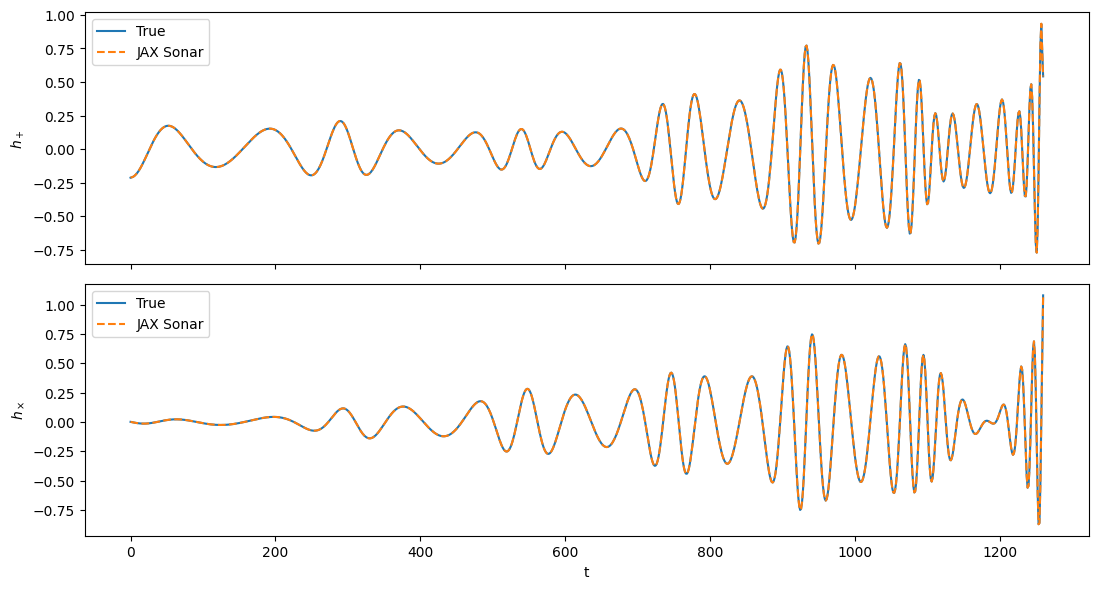

In [ ]:
(final_loss, (final_components, final_roots, final_shell, u0_fit)) = loss_only(
    params, t_full, hp_full, hc_full, LOSS_WEIGHTS
)
final_loss.block_until_ready()
print("final loss:", float(final_loss))
print("raw [waveform, Ricci, frequency, boundary]:", np.asarray(final_components))
print("mean horizon proxy:", float(jnp.mean(final_roots)))

errors = np.asarray(metric_errors_jit(params))
labels = ["g_tt", "g_rr", "g_thth", "g_phph", "g_tph"]
radii = [2, 3, 4, 5, 6, 12, 20]
print("\nMetric relative L2 error across theta (%)")
print("component", *[f"r={r}" for r in radii])
for label, row in zip(labels, errors):
    print(label, *[f"{x:.3f}" for x in row])

trajectory = jax.jit(integrate_network)(
    params["metric"], u0_fit, t_full
)
hp_pred, hc_pred = jax.vmap(
    lambda theta: create_gravityWave(t_full, trajectory, a_true, theta_obs=theta)
)(theta_observed.astype(t_full.dtype))

print("Recovered u0:", np.asarray(u0_fit))
print("True u0:", np.asarray(U0))
print("Mass shell:", float(final_shell))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(np.asarray(t_full), np.asarray(hp_full[0]), label="True")
axes[0].plot(np.asarray(t_full), np.asarray(hp_pred[0]), "--", label="JAX Sonar")
axes[0].set_ylabel(r"$h_+$")
axes[0].legend()
axes[1].plot(np.asarray(t_full), np.asarray(hc_full[0]), label="True")
axes[1].plot(np.asarray(t_full), np.asarray(hc_pred[0]), "--", label="JAX Sonar")
axes[1].set_ylabel(r"$h_\times$")
axes[1].set_xlabel("t")
axes[1].legend()
plt.tight_layout()

save_checkpoint(FINAL_PATH, params, len(schedule) - 1, schedule[-1][1] - 1, n, histories)
print("saved:", FINAL_PATH)

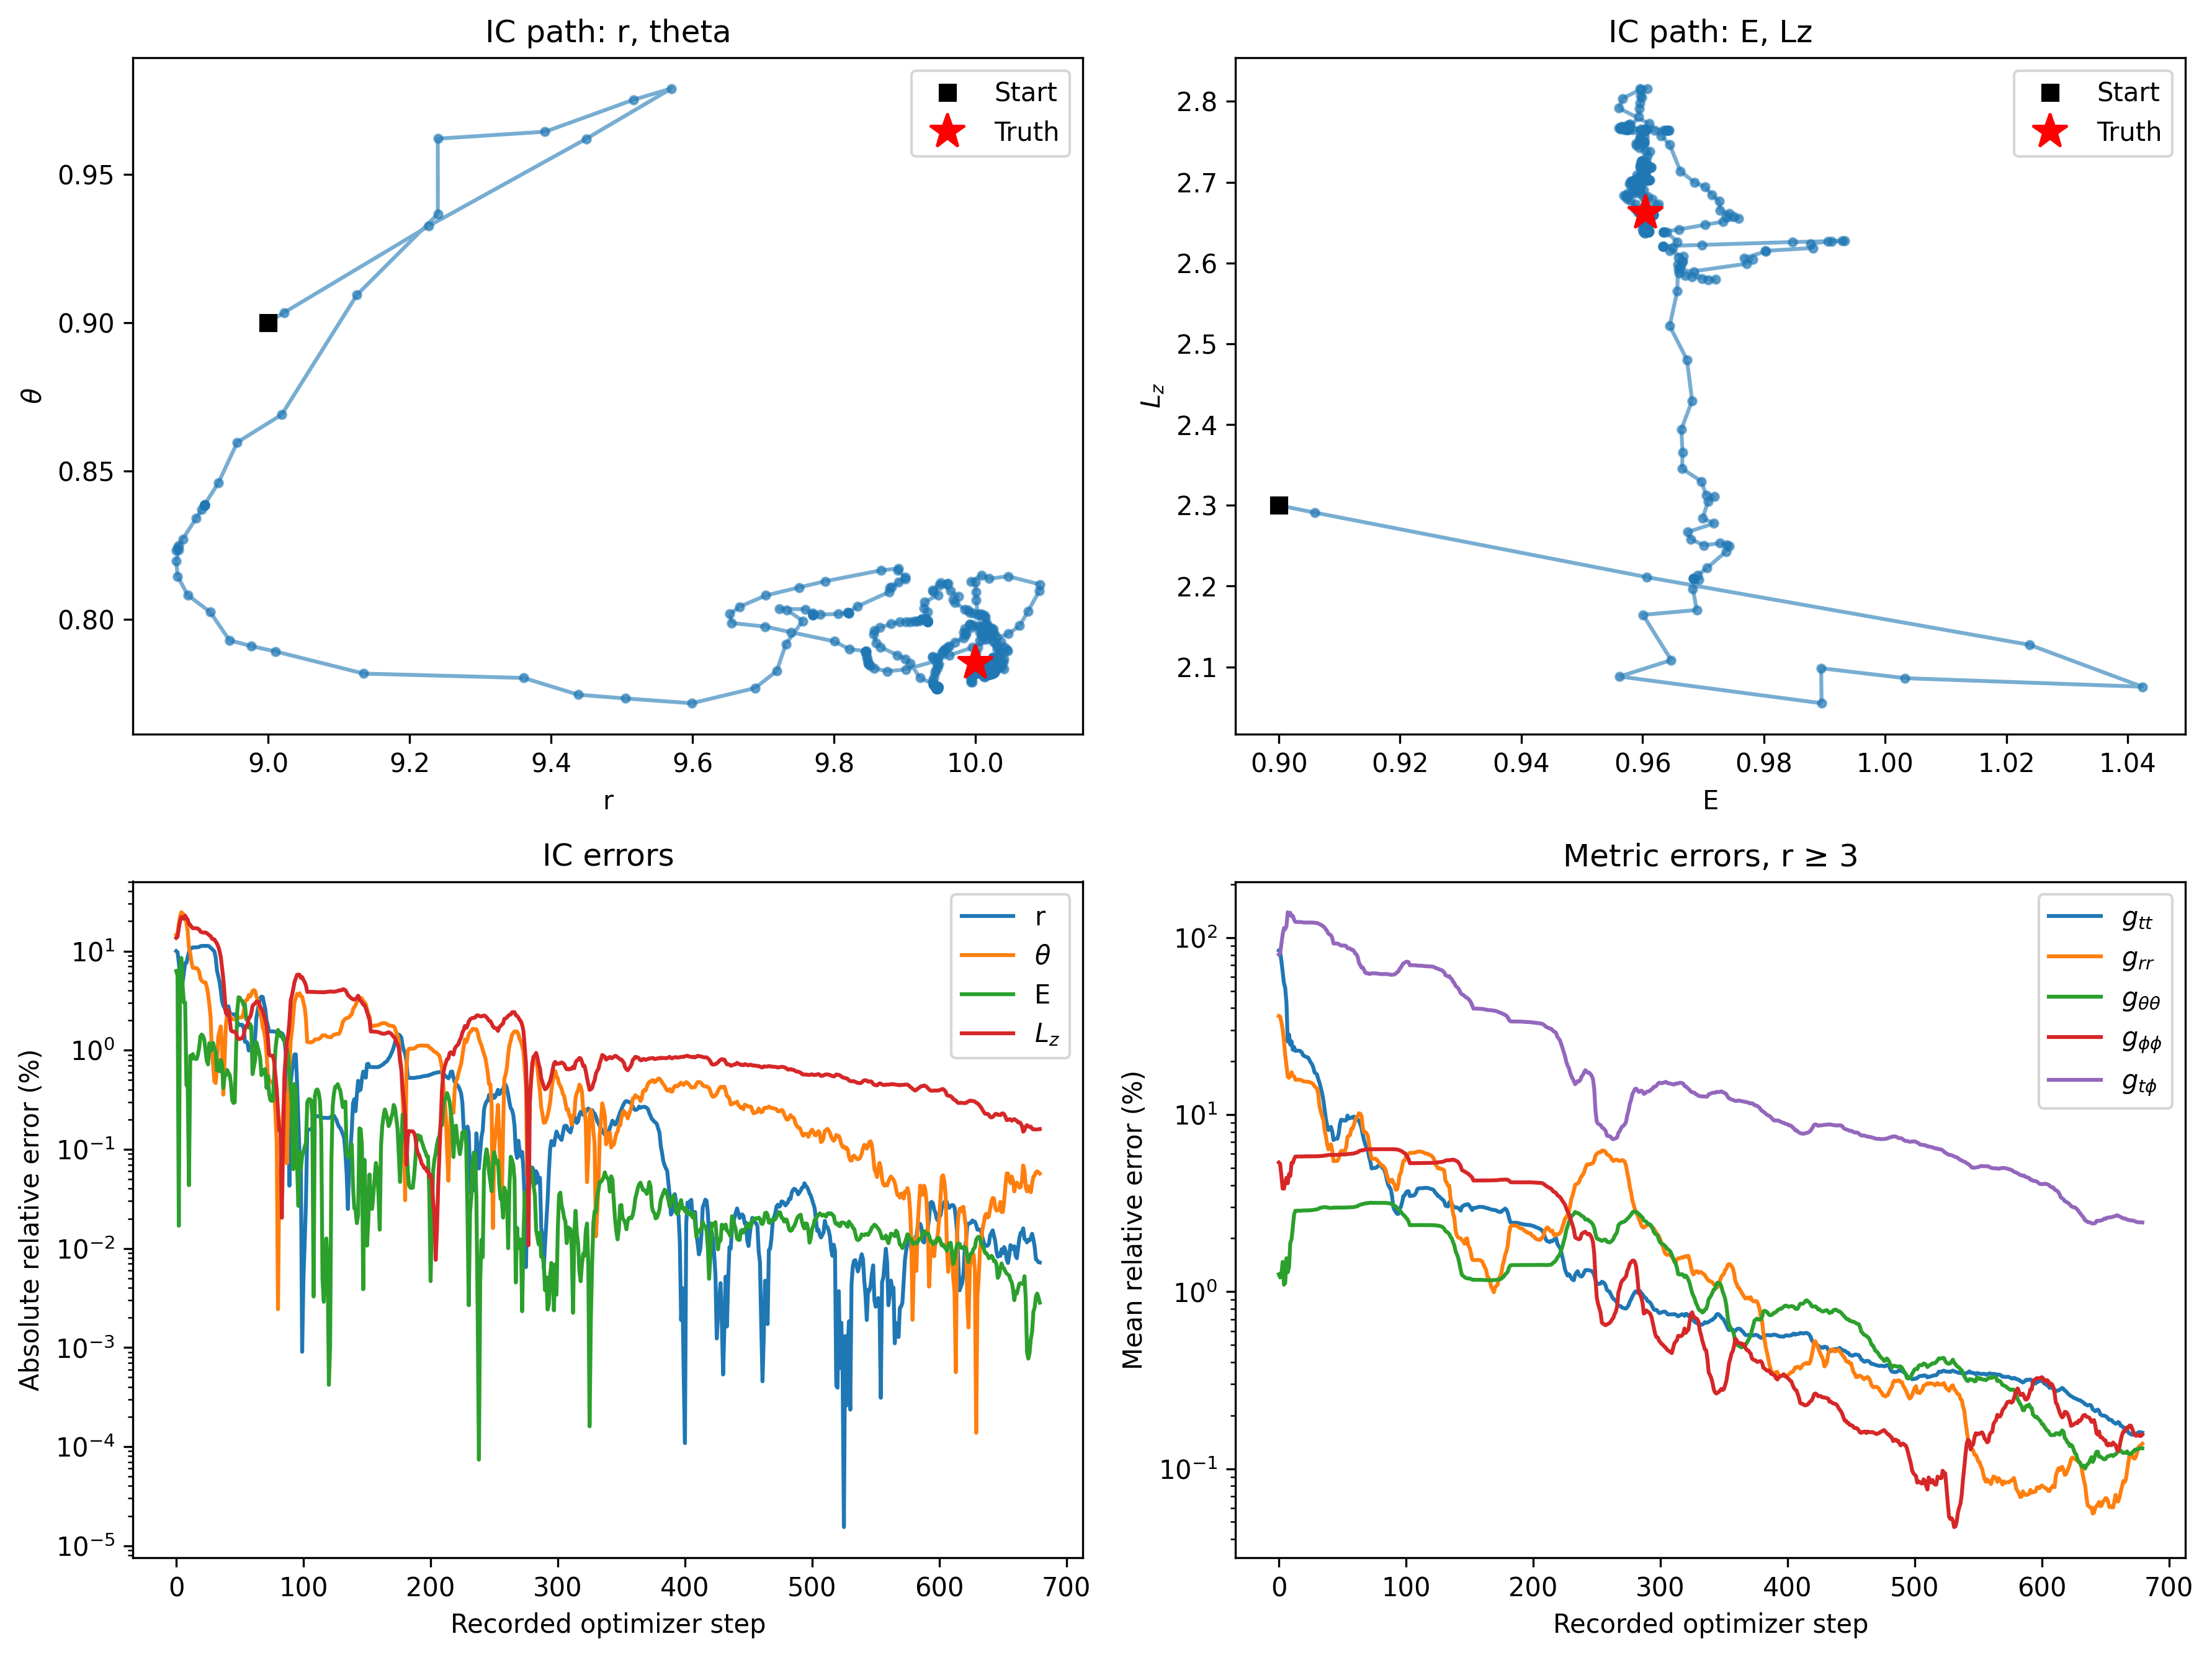

In [ ]:
ic = np.asarray(histories["monitor_ic"])
metric = np.asarray(histories["monitor_metric"])
steps = np.arange(len(ic))

ic_true = np.asarray([
    U0[1],
    U0[2],
    -U0[4],
    U0[7],
], dtype=float)

ic_error = 100 * np.abs((ic - ic_true) / ic_true)
ic_error = np.maximum(ic_error, 1e-12)

metric_labels = [
    r"$g_{tt}$", r"$g_{rr}$", r"$g_{\theta\theta}$",
    r"$g_{\phi\phi}$", r"$g_{t\phi}$",
]

fig, ax = plt.subplots(2, 2, figsize=(12, 9), dpi = 300)

# r-theta path
ax[0, 0].plot(ic[:, 0], ic[:, 1], ".-", alpha=0.6)
ax[0, 0].plot(ic[0, 0], ic[0, 1], "ks", label="Start")
ax[0, 0].plot(ic_true[0], ic_true[1], "r*", ms=14, label="Truth")
ax[0, 0].set(xlabel="r", ylabel=r"$\theta$", title="IC path: r, theta")
ax[0, 0].legend()

# E-Lz path
ax[0, 1].plot(ic[:, 2], ic[:, 3], ".-", alpha=0.6)
ax[0, 1].plot(ic[0, 2], ic[0, 3], "ks", label="Start")
ax[0, 1].plot(ic_true[2], ic_true[3], "r*", ms=14, label="Truth")
ax[0, 1].set(xlabel="E", ylabel=r"$L_z$", title="IC path: E, Lz")
ax[0, 1].legend()

# IC errors
for i, label in enumerate(["r", r"$\theta$", "E", r"$L_z$"]):
    ax[1, 0].plot(steps, ic_error[:, i], label=label)

ax[1, 0].set_yscale("log")
ax[1, 0].set(
    xlabel="Recorded optimizer step",
    ylabel="Absolute relative error (%)",
    title="IC errors",
)
ax[1, 0].legend()

# Metric errors
for i, label in enumerate(metric_labels):
    ax[1, 1].plot(steps, metric[:, i], label=label)

ax[1, 1].set_yscale("log")
ax[1, 1].set(
    xlabel="Recorded optimizer step",
    ylabel="Mean relative error (%)",
    title="Metric errors, r ≥ 3",
)
ax[1, 1].legend()

plt.tight_layout()

In [ ]:
def rel_L2(hp, hc):
    true = hp_full[0] + 1j * hc_full[0]
    pred = hp + 1j * hc
    return 100 * jnp.linalg.norm(pred - true) / jnp.linalg.norm(true)

def wave(traj):
    return create_gravityWave(
        t_full, traj, a_true,
        theta_obs=theta_observed[0].astype(t_full.dtype),
    )

u_true = U0.astype(t_full.dtype)
u_fit  = u0_fit.astype(t_full.dtype)

cases = {
    "Kerr metric + true IC":
        wave(jax.jit(integrate_kerr)(u_true, t_full)),

    "Kerr metric + learned IC":
        wave(jax.jit(integrate_kerr)(u_fit, t_full)),

    "Learned metric + true IC":
        wave(jax.jit(integrate_network)(params["metric"], u_true, t_full)),

    "Learned metric + learned IC":
        wave(jax.jit(integrate_network)(params["metric"], u_fit, t_full)),
}

for name, (hp, hc) in cases.items():
    print(f"{name:30s}: {float(rel_L2(hp, hc)):.6f}%")

Kerr metric + true IC         : 0.000000%
Kerr metric + learned IC      : 116.448491%
Learned metric + true IC      : 112.302736%
Learned metric + learned IC   : 0.156113%


# Diagnostics

In [ ]:
from prettytable import PrettyTable
import time

def rel_L2_error(pred, true, eps = 1e-12):
  return 100 * torch.sqrt(
                          torch.sum((pred - true) ** 2) / (torch.sum((true) ** 2) + eps)
                         )

# -------- Psuedo-code structure --------
# for each radius:
  # evaluate predicted metric at each \theta on a grid [π/20, π/4, π/3, π/2]
  # stack the \theta-profile of the metrics into a tensor of shape [n_theta, 4, 4]
  # compute L2 error for each metric component (i.e., g_tt, g_rr, etc.) across all theta values via L2(g_pred[:, \mu, \nu], g_true[:, \mu, \nu])
  # add that relative angular-profile error at a given radius for a given metric component as a row to the diagnostics table

def log_diagnostics(
    network, total_loss,
    w, r, f, b, roots, n,
    elapsed_time
  ):

  r_grid = [2, 3, 4, 5, 6, 12, 20] # Use these explicit r values
  θ_grid = [π/20, π/4, π/3, π/2] # Use these explicit θ values

  gtt_error_vals = []
  grr_error_vals = []
  gθθ_error_vals = []
  gϕϕ_error_vals = []
  gtϕ_error_vals = []
  ricci_error_vals = []

  param = next(network.parameters())

  for r_val in r_grid:
    pred_vec = []
    true_vec = []
    ricci_at_radius = []

    for θ in θ_grid:
      r_t = torch.tensor(r_val, dtype = param.dtype, device = param.device)
      θ_t = torch.tensor(θ, dtype = param.dtype, device = param.device)

      pred_g = metric_from_network(network, r_t, θ_t)
      true_g = g_Kerr(r_t, θ_t)

      pred_vec.append(pred_g)
      true_vec.append(true_g)

    pred_vec = torch.stack(pred_vec)
    true_vec = torch.stack(true_vec)

    gtt_error_vals.append(rel_L2_error(pred_vec[:, 0, 0], true_vec[:, 0, 0]).detach().item())
    grr_error_vals.append(rel_L2_error(pred_vec[:, 1, 1], true_vec[:, 1, 1]).detach().item())
    gθθ_error_vals.append(rel_L2_error(pred_vec[:, 2, 2], true_vec[:, 2, 2]).detach().item())
    gϕϕ_error_vals.append(rel_L2_error(pred_vec[:, 3, 3], true_vec[:, 3, 3]).detach().item())
    gtϕ_error_vals.append(rel_L2_error(pred_vec[:, 0, 3], true_vec[:, 0, 3]).detach().item())

  metric_table = PrettyTable()
  metric_table.title = "Metric Relative L2 Error Across θ (%)"
  metric_table.field_names = [
      "Component",
      *[f"r={r_val}" for r_val in r_grid]
  ]

  metric_table.add_row(["g_tt", *gtt_error_vals])
  metric_table.add_row(["g_rr", *grr_error_vals])
  metric_table.add_row(["g_θθ", *gθθ_error_vals])
  metric_table.add_row(["g_ϕϕ", *gϕϕ_error_vals])
  metric_table.add_row(["g_tϕ", *gtϕ_error_vals])
  metric_table.float_format = ".2"

  total_value = total_loss.detach().item()
  w_relL2 = 100 * torch.sqrt(w.clamp_min(0)).item()
  r_H = torch.stack(roots).mean().detach().item()

  w_Loss = P_WAVEFORM * w.item()
  r_LOSS = P_RICCI * r.item()
  f_LOSS = P_FREQUENCY * f.item()
  b_LOSS = P_BC * b.item()

  print(
      f"iter={n:4d} | "
      f"time={elapsed_time:7.1f}s | "
      f"total={total_value:.3e} | "
      f"W_err={w_relL2:5.1f}% | "
      f"r_H={r_H:.4f} | "
      f"contrib: W={w_Loss:.2e}, F={f_LOSS:.2e},"
      f"R={r_LOSS:.2e}, BC={b_LOSS:.2e}"
  )

  print(metric_table)

  return metric_table

In [ ]:
def report_gradient_geometry(
    network,
    waveformLoss,
    ricciLoss,
    frequencyLoss,
    boundaryLoss,
):
    params = list(network.parameters())

    terms = {
        "W": (P_WAVEFORM, waveformLoss),
        "R": (P_RICCI, ricciLoss),
        "F": (P_FREQUENCY, frequencyLoss),
        "BC": (P_BC, boundaryLoss),
    }

    gradients = {}
    norms = {}
    weighted_values = {}

    for label, (weight, raw_loss) in terms.items():
        component_grads = torch.autograd.grad(
            weight * raw_loss,
            params,
            retain_graph=True,
            create_graph=False,
            allow_unused=True,
        )

        flat_grad = torch.cat([
            (
                grad.reshape(-1)
                if grad is not None
                else torch.zeros_like(param).reshape(-1)
            )
            for grad, param in zip(component_grads, params)
        ])

        gradients[label] = flat_grad
        norms[label] = torch.linalg.vector_norm(flat_grad)
        weighted_values[label] = (
            weight * raw_loss
        ).detach().item()

    waveform_norm = norms["W"]

    def cosine(label_a, label_b):
        denominator = norms[label_a] * norms[label_b]

        if denominator.detach().item() <= 1e-30:
            return float("nan")

        return (
            torch.dot(
                gradients[label_a],
                gradients[label_b],
            )
            / denominator
        ).detach().item()

    summary = PrettyTable()
    summary.title = "Weighted Loss and Gradient Geometry"
    summary.field_names = [
        "Term",
        "Weighted loss",
        "|weighted gradient|",
        "|grad| / |grad W|",
        "cos(term, W)",
    ]

    for label in terms:
        ratio = (
            norms[label] / (waveform_norm + 1e-30)
        ).detach().item()

        summary.add_row([
            label,
            f"{weighted_values[label]:.6e}",
            f"{norms[label].detach().item():.6e}",
            f"{ratio:.6e}",
            f"{cosine(label, 'W'):+.6f}",
        ])

    print(summary)

    labels = list(terms.keys())

    cosine_table = PrettyTable()
    cosine_table.title = "Pairwise Weighted-Gradient Cosines"
    cosine_table.field_names = [""] + labels

    for label_a in labels:
        cosine_table.add_row([
            label_a,
            *[
                f"{cosine(label_a, label_b):+.5f}"
                for label_b in labels
            ],
        ])

    print(cosine_table)

    return {
        "weighted_losses": weighted_values,
        "gradient_norms": {
            label: norm.detach().item()
            for label, norm in norms.items()
        },
        "pairwise_cosines": {
            (label_a, label_b): cosine(label_a, label_b)
            for label_a in labels
            for label_b in labels
        },
    }

In [ ]:
t_test = t_full
h_plus_true = hp_full
h_cross_true = hc_full

final_total, final_w, final_r, final_f, final_b, final_roots = loss(net)

report_gradient_geometry(net, final_w, final_r, final_f, final_b)

log_diagnostics(
    net,
    final_total,
    final_w,
    final_r,
    final_f,
    final_b,
    final_roots,
    n + result.nit,
    time.time() - start_time
)

In [ ]:
def whole_metric_alpha_scan(
    alphas=None,
    expected_kerr_gate_percent=None,
):
    global WHOLE_METRIC_ALPHA
    global GTPHI_ALPHA
    global t_test, h_plus_true, h_cross_true

    if alphas is None:
        alphas = np.linspace(0.0, 1.0, 11)

    old_whole_alpha = WHOLE_METRIC_ALPHA
    old_gtphi_alpha = GTPHI_ALPHA
    old_t_test = t_test
    old_h_plus = h_plus_true
    old_h_cross = h_cross_true

    rows = []

    try:
        # Scan the complete waveform.
        t_test = t_full
        h_plus_true = hp_full
        h_cross_true = hc_full

        # Ensure the older one-component diagnostic is inactive.
        GTPHI_ALPHA = None

        for alpha in alphas:
            WHOLE_METRIC_ALPHA = float(alpha)

            try:
                total, w, r, f, b, roots = loss(net)

                finite = all(
                    torch.isfinite(value).item()
                    for value in [total, w, r, f, b]
                )

                if not finite:
                    raise FloatingPointError(
                        "Non-finite interpolated loss"
                    )

                root_mean = (
                    torch.stack(roots)
                    .mean()
                    .detach()
                    .item()
                )

                w_value = w.detach().item()

                rows.append({
                    "alpha": float(alpha),
                    "ok": True,
                    "waveform": w_value,
                    "waveform_error_percent": (
                        100 * math.sqrt(max(w_value, 0.0))
                    ),
                    "ricci": r.detach().item(),
                    "frequency": f.detach().item(),
                    "boundary": b.detach().item(),
                    "total": total.detach().item(),
                    "rH": root_mean,
                    "error": "",
                })

                del total, w, r, f, b, roots

            except Exception as exc:
                rows.append({
                    "alpha": float(alpha),
                    "ok": False,
                    "waveform": float("nan"),
                    "waveform_error_percent": float("nan"),
                    "ricci": float("nan"),
                    "frequency": float("nan"),
                    "boundary": float("nan"),
                    "total": float("nan"),
                    "rH": float("nan"),
                    "error": repr(exc),
                })

    finally:
        WHOLE_METRIC_ALPHA = old_whole_alpha
        GTPHI_ALPHA = old_gtphi_alpha
        t_test = old_t_test
        h_plus_true = old_h_plus
        h_cross_true = old_h_cross

    table = PrettyTable()
    table.title = "Whole Covariant-Metric Interpolation Toward Kerr"
    table.field_names = [
        "α",
        "W error (%)",
        "P_W L_W",
        "P_F L_F",
        "P_R L_R",
        "P_BC L_BC",
        "total",
        "r_H",
        "status",
    ]

    for row in rows:
        if row["ok"]:
            table.add_row([
                f"{row['alpha']:.2f}",
                f"{row['waveform_error_percent']:.6f}",
                f"{P_WAVEFORM * row['waveform']:.4e}",
                f"{P_FREQUENCY * row['frequency']:.4e}",
                f"{P_RICCI * row['ricci']:.4e}",
                f"{P_BC * row['boundary']:.4e}",
                f"{row['total']:.4e}",
                f"{row['rH']:.8f}",
                "ok",
            ])
        else:
            table.add_row([
                f"{row['alpha']:.2f}",
                "nan",
                "nan",
                "nan",
                "nan",
                "nan",
                "nan",
                "nan",
                row["error"][:40],
            ])

    print(table)

    valid_rows = [
        row for row in rows
        if row["ok"]
    ]

    if valid_rows:
        alpha_values = [
            row["alpha"]
            for row in valid_rows
        ]

        fig, axes = plt.subplots(
            1, 2,
            figsize=(13, 4.5),
        )

        axes[0].plot(
            alpha_values,
            [
                row["waveform_error_percent"]
                for row in valid_rows
            ],
            marker="o",
        )
        axes[0].set_xlabel(r"$\alpha$")
        axes[0].set_ylabel("Waveform relative L2 (%)")
        axes[0].set_title("Dynamical path toward exact Kerr")
        axes[0].grid(alpha=0.25)

        axes[1].semilogy(
            alpha_values,
            [
                max(
                    P_WAVEFORM * row["waveform"],
                    1e-30,
                )
                for row in valid_rows
            ],
            marker="o",
            label="W",
        )
        axes[1].semilogy(
            alpha_values,
            [
                max(
                    P_FREQUENCY * row["frequency"],
                    1e-30,
                )
                for row in valid_rows
            ],
            marker="o",
            label="F",
        )
        axes[1].semilogy(
            alpha_values,
            [
                max(
                    P_RICCI * row["ricci"],
                    1e-30,
                )
                for row in valid_rows
            ],
            marker="o",
            label="R",
        )
        axes[1].semilogy(
            alpha_values,
            [
                max(
                    P_BC * row["boundary"],
                    1e-30,
                )
                for row in valid_rows
            ],
            marker="o",
            label="BC",
        )
        axes[1].set_xlabel(r"$\alpha$")
        axes[1].set_ylabel("Weighted loss")
        axes[1].set_title("Loss components along interpolation")
        axes[1].grid(alpha=0.25)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    kerr_endpoint = next(
        (
            row for row in rows
            if row["ok"]
            and abs(row["alpha"] - 1.0) < 1e-12
        ),
        None,
    )

    if kerr_endpoint is not None:
        measured = kerr_endpoint[
            "waveform_error_percent"
        ]

        print(
            f"α=1 Kerr endpoint waveform error: "
            f"{measured:.8f}%"
        )

        if expected_kerr_gate_percent is not None:
            difference = (
                measured
                - expected_kerr_gate_percent
            )

            print(
                f"Earlier exact-Kerr gate: "
                f"{expected_kerr_gate_percent:.8f}%"
            )
            print(
                f"Endpoint minus gate: "
                f"{difference:+.8f} percentage points"
            )

            if abs(difference) > 0.05:
                print(
                    "WARNING: α=1 did not reproduce the "
                    "exact-Kerr waveform gate. Check dtype, "
                    "global diagnostic state, time window, "
                    "and waveform references."
                )

    return rows

In [ ]:
dt_plot = assert_uniform_time(t_test).detach().item()
h_true = torch.complex(h_plus_true[0], h_cross_true[0])
h_pred = torch.complex(hp_trained, hc_trained)
plotSpectralDiagnostic(h_true, h_pred, dt=dt_plot)

In [ ]:
plt.figure(dpi=300)

for history, label in [
    (waveform_loss_history, 'Waveform'),
    (frequency_loss_history, 'Frequency'),
    (ricci_loss_history, 'Ricci'),
    (boundaryCondition_loss_history, 'Boundary Condition')
]:
  plt.plot(history, label = label)

# plt.plot(loss_history, 'k', label='total',)
plt.axvline(
    adam_end,
    color="red",
    linestyle="--",
    label="Adam->BFGS"
)
plt.yscale('log')
plt.xlabel('evaluation')
plt.title('Loss Function')
plt.legend()

In [ ]:
t_final_plot = len(t_test)

plt.figure(dpi=300)
plt.plot(t_test.detach()[0:t_final_plot], h_plus_true[0][0:t_final_plot], label = "True", linestyle = "solid")
plt.plot(t_test.detach()[0:t_final_plot], hp_trained.detach()[0:t_final_plot], label = "Predicted", linestyle='dashed')

print("Stride of 10 Elements Comparison:\n")
print("Time:", t_test.detach()[::10])
print("hp_trained.detach:", hp_trained.detach()[::10])
print("h_plus_true:", h_plus_true[0][::10])

plt.legend()

In [ ]:
from prettytable import PrettyTable

def print_metric_error_table(network, r_grid = [2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16, 20]):

    θ_grid = [π/20, π/4, π/3, π/2]

    components = {
        "g_tt": (0,0),
        "g_rr": (1,1),
        "g_θθ": (2,2),
        "g_ϕϕ": (3,3),
        "g_tϕ": (0,3),
    }

    errors = {name: [] for name in components}
    param = next(network.parameters())

    with torch.no_grad():
      for r in r_grid:
        pred_at_r = []
        true_at_r = []

        for θ in θ_grid:
          r_t = torch.tensor(r, dtype = param.dtype)
          θ_t = torch.tensor(θ, dtype = param.dtype)

          pred_at_r.append(metric_from_network(network, r_t, θ_t))
          true_at_r.append(g_Kerr(r_t, θ_t))

        pred_at_r = torch.stack(pred_at_r)
        true_at_r = torch.stack(true_at_r)

        for name, (μ, ν) in components.items():
          error = rel_L2_error(
              pred_at_r[:, μ, ν],
              true_at_r[:, μ, ν]
          )

          errors[name].append(error.item())

    table = PrettyTable()
    table.title = "Metric Relative L2 Error Across θ (%)"
    table.field_names = [
        "Component",
        *[f"r={r:g}" for r in r_grid]
    ]
    table.float_format = ".2"

    for name in components:
      table.add_row([name, *errors[name]])

    print(table)
    return table, errors


In [ ]:
from scipy.optimize import brentq

def horizon_and_rotation_diagnostics(
    network,
    M=1.0,
    a=None,
    r_lo=1.0,
    r_hi=2.01,
    n_r=401,
    theta_values=None,
    far_field_radii=(4.0, 10.0, 14.0, 20.0),
):
    if a is None:
        a = a_true

    if theta_values is None:
        theta_values = [
            math.pi / 20,
            math.pi / 4,
            math.pi / 3,
            math.pi / 2,
        ]

    reference = next(network.parameters())
    dtype = reference.dtype
    device = reference.device

    def scalar_tensor(value):
        return torch.tensor(
            value,
            dtype=dtype,
            device=device,
        )

    def learned_metric(r, theta):
        return metric_from_network(
            network,
            scalar_tensor(r),
            scalar_tensor(theta),
        )

    def inverse_grr_value(r, theta):
        # Valid here because the ansatz has no r cross-terms.
        with torch.no_grad():
            g = learned_metric(r, theta)
            return float((1.0 / g[1, 1]).detach().cpu())

    def metric_rotation_quantities(g, r, theta):
        g_tt = float(g[0, 0].detach().cpu())
        g_tphi = float(g[0, 3].detach().cpu())
        g_phiphi = float(g[3, 3].detach().cpu())

        sin2 = math.sin(theta) ** 2

        omega = -g_tphi / g_phiphi
        J_eff = -r * g_tphi / (2.0 * sin2)

        return {
            "g_tt": g_tt,
            "g_tphi": g_tphi,
            "g_phiphi": g_phiphi,
            "omega": omega,
            "J_eff": J_eff,
        }

    def chi_squared(q, Omega):
        return (
            q["g_tt"]
            + 2.0 * Omega * q["g_tphi"]
            + Omega**2 * q["g_phiphi"]
        )

    # Existing differentiable soft-root output, for comparison.
    metric_fn = lambda x: metric_from_network(
        network,
        x[1],
        x[2],
    )

    with torch.no_grad():
        soft_bc_loss, soft_roots = boundaryConditionLoss(metric_fn)

    soft_root_values = [
        float(root.detach().cpu())
        for root in soft_roots
    ]

    print(
        "BC soft roots at θ=[0, π/2]:",
        [f"{root:.8f}" for root in soft_root_values],
    )
    print(
        f"BC raw loss: {float(soft_bc_loss.detach().cpu()):.6e}"
    )

    # Hard sign-changing roots on a denser diagnostic grid.
    radial_grid = np.linspace(r_lo, r_hi, n_r)
    root_records = []

    for theta in theta_values:
        values = np.array([
            inverse_grr_value(r, theta)
            for r in radial_grid
        ])

        candidate_roots = []

        def add_unique_root(root):
            if not any(
                abs(root - existing) < 1e-8
                for existing in candidate_roots
            ):
                candidate_roots.append(root)

        for i in range(len(radial_grid) - 1):
            y0 = values[i]
            y1 = values[i + 1]

            if not (np.isfinite(y0) and np.isfinite(y1)):
                continue

            if y0 == 0.0:
                add_unique_root(float(radial_grid[i]))
            elif y0 * y1 < 0.0:
                root = brentq(
                    lambda radius: inverse_grr_value(
                        radius,
                        theta,
                    ),
                    radial_grid[i],
                    radial_grid[i + 1],
                )
                add_unique_root(float(root))

        candidate_roots.sort()

        # The event-horizon candidate is the outermost root.
        hard_root = (
            candidate_roots[-1]
            if candidate_roots
            else float("nan")
        )

        endpoint_product = values[0] * values[-1]
        endpoint_bracket = (
            np.isfinite(endpoint_product)
            and endpoint_product <= 0.0
        )

        record = {
            "theta": theta,
            "root": hard_root,
            "n_crossings": len(candidate_roots),
            "endpoint_bracket": endpoint_bracket,
            "g_lo": values[0],
            "g_hi": values[-1],
        }

        if np.isfinite(hard_root):
            with torch.no_grad():
                g_root = learned_metric(
                    hard_root,
                    theta,
                )

            record["root_quantities"] = (
                metric_rotation_quantities(
                    g_root,
                    hard_root,
                    theta,
                )
            )
        else:
            record["root_quantities"] = None

        root_records.append(record)

    finite_roots = np.array([
        record["root"]
        for record in root_records
        if np.isfinite(record["root"])
    ])

    omega_h_values = np.array([
        record["root_quantities"]["omega"]
        for record in root_records
        if record["root_quantities"] is not None
    ])

    r_plus = M + math.sqrt(M**2 - a**2)
    Omega_H_true = a / (2.0 * M * r_plus)

    rH_mean = (
        float(np.mean(finite_roots))
        if len(finite_roots)
        else float("nan")
    )
    rH_std = (
        float(np.std(finite_roots))
        if len(finite_roots)
        else float("nan")
    )

    Omega_H_learned = (
        float(np.mean(omega_h_values))
        if len(omega_h_values)
        else float("nan")
    )
    Omega_H_learned_std = (
        float(np.std(omega_h_values))
        if len(omega_h_values)
        else float("nan")
    )

    horizon_table = PrettyTable()
    horizon_table.title = "Hard Horizon and Killing-Generator Diagnostics"
    horizon_table.field_names = [
        "θ",
        "r_H",
        "# roots",
        "endpoint bracket?",
        "ω(r_H,θ)",
        "χ²(r_H; Ω_Kerr)",
        "χ²(r_H; <ω_H>)",
        "χ²(r_+; Ω_Kerr)",
    ]

    for record in root_records:
        theta = record["theta"]
        root = record["root"]
        q_root = record["root_quantities"]

        if q_root is None:
            horizon_table.add_row([
                f"{theta:.5f}",
                "none",
                record["n_crossings"],
                record["endpoint_bracket"],
                "nan",
                "nan",
                "nan",
                "nan",
            ])
            continue

        chi_root_true_Omega = chi_squared(
            q_root,
            Omega_H_true,
        )
        chi_root_learned_Omega = chi_squared(
            q_root,
            Omega_H_learned,
        )

        with torch.no_grad():
            g_at_true_rplus = learned_metric(
                r_plus,
                theta,
            )

        q_at_true_rplus = metric_rotation_quantities(
            g_at_true_rplus,
            r_plus,
            theta,
        )
        chi_at_true_rplus = chi_squared(
            q_at_true_rplus,
            Omega_H_true,
        )

        horizon_table.add_row([
            f"{theta:.5f}",
            f"{root:.8f}",
            record["n_crossings"],
            record["endpoint_bracket"],
            f"{q_root['omega']:.8f}",
            f"{chi_root_true_Omega:+.4e}",
            f"{chi_root_learned_Omega:+.4e}",
            f"{chi_at_true_rplus:+.4e}",
        ])

    print(horizon_table)

    print(f"True Kerr r_+          = {r_plus:.10f}")
    print(f"Learned hard-root mean = {rH_mean:.10f}")
    print(f"Learned hard-root std  = {rH_std:.4e}")

    if np.isfinite(rH_mean):
        print(
            "r_H relative error     = "
            f"{100 * (rH_mean - r_plus) / r_plus:+.4f}%"
        )

    print(f"True Kerr Ω_H          = {Omega_H_true:.10f}")
    print(f"Learned <ω_H>          = {Omega_H_learned:.10f}")
    print(f"Learned std(ω_H)       = {Omega_H_learned_std:.4e}")

    if np.isfinite(Omega_H_learned):
        print(
            "Ω_H relative error     = "
            f"{100 * (Omega_H_learned - Omega_H_true) / Omega_H_true:+.4f}%"
        )

    print(
        "Endpoint brackets: "
        f"{sum(r['endpoint_bracket'] for r in root_records)}"
        f"/{len(root_records)}"
    )

    # Radial frame-dragging and effective-angular-momentum table.
    rotation_thetas = [
        math.pi / 4,
        math.pi / 3,
        math.pi / 2,
    ]

    rotation_table = PrettyTable()
    rotation_table.title = "Frame Dragging and Effective Angular Momentum"
    rotation_table.field_names = [
        "r",
        "θ",
        "ω_NN",
        "ω_Kerr",
        "ω error (%)",
        "J_eff NN",
        "J_eff Kerr",
        "J error (%)",
    ]

    for radius in far_field_radii:
        for theta in rotation_thetas:
            r_tensor = scalar_tensor(radius)
            theta_tensor = scalar_tensor(theta)

            with torch.no_grad():
                g_nn = metric_from_network(
                    network,
                    r_tensor,
                    theta_tensor,
                )
                g_true = g_Kerr(
                    r_tensor,
                    theta_tensor,
                    M=M,
                    a=a,
                )

            q_nn = metric_rotation_quantities(
                g_nn,
                radius,
                theta,
            )
            q_true = metric_rotation_quantities(
                g_true,
                radius,
                theta,
            )

            omega_error = (
                100
                * abs(q_nn["omega"] - q_true["omega"])
                / (abs(q_true["omega"]) + 1e-30)
            )
            J_error = (
                100
                * abs(q_nn["J_eff"] - q_true["J_eff"])
                / (abs(q_true["J_eff"]) + 1e-30)
            )

            rotation_table.add_row([
                f"{radius:.1f}",
                f"{theta:.5f}",
                f"{q_nn['omega']:.6e}",
                f"{q_true['omega']:.6e}",
                f"{omega_error:.3f}",
                f"{q_nn['J_eff']:.6f}",
                f"{q_true['J_eff']:.6f}",
                f"{J_error:.3f}",
            ])

    print(rotation_table)

    return {
        "soft_roots": soft_root_values,
        "hard_root_records": root_records,
        "r_plus_true": r_plus,
        "rH_mean": rH_mean,
        "rH_std": rH_std,
        "Omega_H_true": Omega_H_true,
        "Omega_H_learned": Omega_H_learned,
        "Omega_H_learned_std": Omega_H_learned_std,
    }

In [ ]:
horizon_diagnostics = horizon_and_rotation_diagnostics(net)

In [ ]:
"""
Sonar v15 — upgraded figures.  Paste this whole file into ONE new Colab cell,
after the existing plotting cells.  It only uses names already in the notebook:
metric_from_network, g_Kerr, BoyerLindquist2Cartesian, a_true, ra_true.

Provides
    plotGeodesicProjections(soln_true, soln_pred, a_spin)     # drop-in replacement
    plot_radius_overlay(t, traj_true, traj_pred)
    compare_metrics_v2(NN)                                     # replaces compare_metrics
    angular_comparison_metrics_v2(NN)                          # replaces angular_...
    plot_horizon_surface(NN)
"""
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from scipy.optimize import brentq

# ----------------------------------------------------------------- style
# Four hues for the theta series.  This replaces C0-C3: matplotlib's default
# C1 (orange) and C2 (green) are ΔE 0.7 apart under protanopia -- i.e. the
# theta=pi/3 and theta=pi/4 curves are the SAME COLOR for a protan reader.
# These four are the nearest visual equivalents that pass; all pairs are
# ΔE >= 10 under deutan/protan and all clear 3:1 contrast on white.
THETA_COLORS = ["#0072B2", "#B25E00", "#00806A", "#C0392B"]

TRUE_COLOR = "red"     # neutral: truth is the reference, not a series
PRED_COLOR = "#0072B2"
SPIN_COLOR = "#D62728"
BH_COLOR = "#0B0B0B"
ERGO_COLOR = "#7A5C9E"

TRUE_KW = dict(color=TRUE_COLOR, lw=1.6, alpha=0.40, solid_capstyle="round", zorder=2)
PRED_KW = dict(color=PRED_COLOR, lw=1.6, ls=(0, (5, 2.5)), zorder=3)
# white casing so the dashed prediction stays legible on top of the true curve
CASING = [pe.Stroke(linewidth=1.6, foreground="white"), pe.Normal()]


def _grid(ax):
    ax.grid(True, lw=0.4, alpha=0.25, zorder=0)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)


def _r_plus(a, M=1.0):
    return M + math.sqrt(max(M * M - a * a, 0.0))


def _r_ergo(theta, a, M=1.0):
    return M + np.sqrt(np.maximum(M * M - (a * np.cos(theta)) ** 2, 0.0))


# ================================================================= 1. geodesics
def _add_black_hole_3d(ax, a, M=1.0, arrow_scale=2.0, show_ergo=False):
    """Solid horizon sphere + translucent ergosphere + red spin arrow."""
    rp = _r_plus(a, M)
    u = np.linspace(0, 2 * np.pi, 60)
    v = np.linspace(0, np.pi, 40)
    U, V = np.meshgrid(u, v)

    # horizon: a coordinate sphere of radius r_+, because the notebook's
    # BoyerLindquist2Cartesian uses x = r sin(th) cos(ph) (it ignores `a`).
    ax.plot_surface(rp * np.sin(V) * np.cos(U), rp * np.sin(V) * np.sin(U),
                    rp * np.cos(V), color="#141414", shade=True,
                    linewidth=0, antialiased=True, zorder=1)

    if show_ergo:
        rE = _r_ergo(V, a, M)
        ax.plot_surface(rE * np.sin(V) * np.cos(U), rE * np.sin(V) * np.sin(U),
                        rE * np.cos(V), color=ERGO_COLOR, alpha=0.13,
                        shade=False, linewidth=5, antialiased=True)

    L = arrow_scale * 3.2 * rp
    ax.quiver(0, 0, 0, 0, 0, L, color=SPIN_COLOR, lw=2.0,
              arrow_length_ratio=0.25, zorder=10)

def _add_black_hole_2d(ax, a, M=1.0, spin_arrow=False, arrow_len=None):
    rp = _r_plus(a, M)
    ax.add_patch(Circle((0, 0), rp, facecolor=BH_COLOR, edgecolor="none", zorder=4))

    th = np.linspace(0, 2 * np.pi, 400)
    if spin_arrow:                      # poloidal plane: ergosphere is oblate
        L = arrow_len if arrow_len is not None else 3.0 * rp
        ax.annotate("", xy=(0, L), xytext=(0, 0), zorder=6,
                    arrowprops=dict(arrowstyle="-|>", color=SPIN_COLOR, lw=1.8))


def plotGeodesicProjections(soln_true, soln_pred, a_spin, show_ergo=False,
                            lim=None):
    """3D + three 2D projections, with the black hole drawn in every panel."""
    x_t, y_t, z_t = BoyerLindquist2Cartesian(soln_true[:, 1], soln_true[:, 2],
                                             soln_true[:, 3], a_spin)
    x_p, y_p, z_p = BoyerLindquist2Cartesian(soln_pred[:, 1], soln_pred[:, 2],
                                             soln_pred[:, 3], a_spin)
    T = [v.detach().cpu().numpy() for v in (x_t, y_t, z_t)]
    P = [v.detach().cpu().numpy() for v in (x_p, y_p, z_p)]

    fig = plt.figure(figsize=(13.5, 11), dpi=300)

    ax1 = fig.add_subplot(221, projection="3d")
    _add_black_hole_3d(ax1, a_spin, show_ergo=False)
    ax1.plot(*T, label="True", **TRUE_KW)
    ax1.plot(*P, label="Predicted", path_effects=CASING, **PRED_KW)
    ax1.set_title("3D predicted geodesic", pad=2)
    ax1.set_xlabel("x / M"); ax1.set_ylabel("y / M"); ax1.set_zlabel("z / M")
    if lim is None:
        lim = 1.05 * max(np.abs(np.concatenate(T)).max(), 1.0)
    ax1.set_xlim(-lim, lim); ax1.set_ylim(-lim, lim); ax1.set_zlim(-lim, lim)
    ax1.view_init(elev=22, azim=-58)
    try:
        ax1.set_box_aspect((1, 1, 1))
    except Exception:
        pass
    ax1.legend(loc="upper left", frameon=False, fontsize=9)

    panels = [(222, T[0], T[1], P[0], P[1], "x", "y", "X–Y  (precession)", False),
              (223, T[0], T[2], P[0], P[2], "x", "z", "X–Z  (wobble)", True),
              (224, T[1], T[2], P[1], P[2], "y", "z", "Y–Z  (inclination)", True)]

    for pos, a1, b1, a2, b2, xl, yl, title, poloidal in panels:
        ax = fig.add_subplot(pos)
        _grid(ax)
        span = lim if lim is not None else \
            1.08 * max(np.abs(np.concatenate([a1, b1])).max(), 1.0)
        _add_black_hole_2d(ax, a_spin, spin_arrow=poloidal, arrow_len=0.45 * span)
        ax.plot(a1, b1, **TRUE_KW)
        ax.plot(a2, b2, path_effects=CASING, **PRED_KW)
        ax.set_title(title, pad=4)
        ax.set_xlabel(f"{xl} / M"); ax.set_ylabel(f"{yl} / M")
        ax.set_xlim(-span, span); ax.set_ylim(-span, span)
        ax.set_aspect("equal")

    fig.suptitle("Sonar v15", y=0.985, fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    return fig

plotGeodesicProjections(trajectory_gate, traj, a_true)

In [ ]:
# ================================================================= 2. r(t)
def plot_radius_overlay(t, traj_true, traj_pred, rp_horizon=None, a=None):
    """r(t) for the prediction drawn over the truth, with a residual strip."""
    if a is None:
        a = a_true
    tt = np.asarray(t.detach().cpu() if torch.is_tensor(t) else t, dtype=float)
    r_t = traj_true[:, 1].detach().cpu().numpy()
    r_p = traj_pred[:, 1].detach().cpu().numpy()
    n = min(len(tt), len(r_t), len(r_p))
    tt, r_t, r_p = tt[:n], r_t[:n], r_p[:n]

    fig, (ax, axr) = plt.subplots(
        2, 1, figsize=(9, 6.2), dpi=300, sharex=True,
        gridspec_kw=dict(height_ratios=[3, 1], hspace=0.08))

    ax.plot(tt, r_t, label="True", **TRUE_KW)
    ax.plot(tt, r_p, label="Predicted", path_effects=CASING, **PRED_KW)

    rp = _r_plus(a) if rp_horizon is None else rp_horizon
    ax.axhline(rp, color=BH_COLOR, lw=1.2, ls="-", alpha=0.9)
    ax.axhspan(0, rp, color="red", alpha=0.10, lw=0)
    ax.text(tt[0], rp-5e-1, r"  Event Horizon $r_+$", color=BH_COLOR, va="top", fontsize=9)
    ax.axhline(2.0, color=ERGO_COLOR, lw=1.0, ls=":", alpha=0.9)
    ax.text(tt[0], 2.0, r"  ergosphere ($\theta=\pi/2$)", color=ERGO_COLOR,
            va="bottom", fontsize=8)

    _grid(ax)
    ax.set_ylabel(r"$r\,/\,M$")
    ax.set_ylim(bottom=0)
    ax.legend(frameon=True, loc="upper right")
    rel = 100 * np.linalg.norm(r_p - r_t) / np.linalg.norm(r_t)
    ax.set_title(f"Predicted orbital radius:  relative $L_2$ error = {rel:.4f} %", pad=6)

    axr.axhline(0, color=TRUE_COLOR, lw=1.0, alpha=0.6)
    axr.plot(tt, r_p - r_t, color=PRED_COLOR, lw=1.3)
    _grid(axr)
    axr.set_xlabel(r"$t\,/\,M$")
    axr.set_ylabel(r"$\Delta r$")
    fig.tight_layout()
    return fig

plot_radius_overlay(t_test, trajectory_gate, traj)

In [ ]:

# ================================================================= 3. metrics
_COMPONENTS = [r"g_{tt}", r"g_{rr}", r"g_{\theta\theta}",
               r"g_{\phi\phi}", r"g_{t\phi}"]
_INDEX = [(0, 0), (1, 1), (2, 2), (3, 3), (0, 3)]


def _sample_component(NN, idx, r_vals, theta_vals):
    dtype = next(NN.parameters()).dtype
    pred = np.zeros((len(r_vals), len(theta_vals)))
    true = np.zeros_like(pred)
    for j, th in enumerate(theta_vals):
        tht = torch.tensor(th, dtype=dtype)
        for i, rr in enumerate(r_vals):
            rt = torch.tensor(float(rr), dtype=dtype)
            with torch.no_grad():
                true[i, j] = float(g_Kerr(rt, tht)[idx])
                pred[i, j] = float(metric_from_network(NN, rt, tht)[idx])
    return pred, true


def _metric_figure(r_vals, theta_vals, pred, true, title, ylabel,
                   residual="absolute"):
    fig, (ax, axr) = plt.subplots(
        2, 1, figsize=(8.2, 7.0), dpi=300, sharex=True,
        gridspec_kw=dict(height_ratios=[3, 1.15], hspace=0.08))

    for j, th in enumerate(theta_vals):
        c = THETA_COLORS[j % len(THETA_COLORS)]
        # truth: thick and recessive -- it is the backdrop, not a competing line
        ax.plot(r_vals, true[:, j], color=c, lw=1.5, alpha=0.32,
                solid_capstyle="round", zorder=2)
        # prediction: thin, dashed, full-strength, cased in white so it never
        # disappears into the true curve when the two agree
        ax.plot(r_vals, pred[:, j], color=c, lw=1.5, ls=(0, (5, 2.5)),
                zorder=3 + j, path_effects=CASING)

        d = pred[:, j] - true[:, j]
        if residual == "relative":
            # mask where the true value passes near zero (g_tt at the
            # ergosphere) -- a relative error there is meaningless
            scale = np.nanmax(np.abs(true[:, j])) + 1e-30
            with np.errstate(divide="ignore", invalid="ignore"):
                d = 100 * d / np.where(np.abs(true[:, j]) > 1e-3 * scale,
                                       true[:, j], np.nan)
        axr.plot(r_vals, d, color=c, lw=1.5)

    _grid(ax); _grid(axr)
    ax.set_ylabel(ylabel)

    axr.axhline(0, color="#444444", lw=1.0, alpha=0.7)
    axr.set_xlabel(r"$r\,/\,M$")
    axr.set_ylabel("pred − true" if residual == "absolute" else "error (%)")

    handles = [Line2D([0], [0], color=THETA_COLORS[j % 4], lw=2.6,
                      label=rf"$\theta={theta_vals[j]:.2f}$")
               for j in range(len(theta_vals))]
    handles += [Line2D([0], [0], color="#444444", lw=3.4, alpha=0.4, label="True"),
                Line2D([0], [0], color="#444444", lw=1.5, ls=(0, (5, 2.5)),
                       label="Predicted")]
    ax.legend(handles=handles, frameon=False, fontsize=9, ncol=3,
              loc="lower left", bbox_to_anchor=(0.0, 1.02, 1.0, 0.16),
              mode="expand", borderaxespad=0.0)
    fig.suptitle(title, y=1.06, fontsize=12)
    fig.tight_layout()
    return fig


def compare_metrics_v2(NN, n_r=60, residual="relative"):
    """Same content as compare_metrics, with the prediction readable on top."""
    r_vals = np.linspace(2, ra_true, n_r)
    theta_vals = [math.pi / 2, math.pi / 3, math.pi / 4, math.pi / 20]
    figs, preds, trues = [], [], []
    for k, idx in enumerate(_INDEX):
        p, t = _sample_component(NN, idx, r_vals, theta_vals)
        figs.append(_metric_figure(r_vals, theta_vals, p, t,
                                   rf"${_COMPONENTS[k]}$ component",
                                   rf"${_COMPONENTS[k]}$", residual))
        preds.append(p); trues.append(t)
    return figs, preds, trues

def angular_comparison_metrics_v2(NN, n_r=60):
    """Angular structure: each curve minus its own theta=pi/2 value."""
    r_vals = np.linspace(2, ra_true, n_r)
    theta_vals = [math.pi / 2, math.pi / 3, math.pi / 4, 0.0]
    figs, preds, trues = [], [], []
    for k, idx in enumerate(_INDEX):
        p, t = _sample_component(NN, idx, r_vals, theta_vals)
        pd, td = p - p[:, 0:1], t - t[:, 0:1]
        figs.append(
            _metric_figure(
                r_vals,
                theta_vals,
                pd,
                td,
                rf"${_COMPONENTS[k]}$ angular structure: $g_{{\mu\nu}}(r, \theta)-g_{{\mu\nu}}(r, \pi/2)$",
                rf"$\Delta_\theta {_COMPONENTS[k]}$",
                residual="absolute"
            )
        )
        preds.append(pd); trues.append(td)
    return figs, preds, trues

afigs, pd, td = angular_comparison_metrics_v2(net)

In [ ]:
# ================================================================= 4. horizon
def learned_horizon_profile(NN, n_theta=61, r_lo=1.0, r_hi=2.5, n_scan=400):
    """Root-find g^{rr}(r, theta) = 0 for each theta.  Returns (theta, r_H)."""
    dtype = next(NN.parameters()).dtype

    def g_rr_inv(r, th):
        with torch.no_grad():
            g = metric_from_network(NN,
                                    torch.tensor(float(r), dtype=dtype),
                                    torch.tensor(float(th), dtype=dtype))
            return float(1.0 / g[1, 1])

    thetas = np.linspace(0.0, np.pi / 2, n_theta)
    scan = np.linspace(r_lo, r_hi, n_scan)
    out = np.full(n_theta, np.nan)
    for i, th in enumerate(thetas):
        v = np.array([g_rr_inv(r, th) for r in scan])
        s = np.where(np.sign(v[:-1]) * np.sign(v[1:]) < 0)[0]
        if len(s):
            k = s[0]
            out[i] = brentq(lambda r: g_rr_inv(r, th), scan[k], scan[k + 1],
                            xtol=1e-12)
    return thetas, out


def plot_horizon_surface(NN, a=None, n_theta=61, show_3d=True):
    if a is None:
        a = a_true
    rp = _r_plus(a)
    th, rH = learned_horizon_profile(NN, n_theta=n_theta)
    ok = np.isfinite(rH)

    fig = plt.figure(figsize=(15, 5.0), dpi=300)

    # -- (a) 3D: learned surface of revolution vs the true sphere
    ax = fig.add_subplot(131, projection="3d")
    if show_3d:
        thf = np.concatenate([th, np.pi - th[::-1]])
        rf_ = np.concatenate([rH, rH[::-1]])
        good = np.isfinite(rf_)
        phi = np.linspace(0, 2 * np.pi, 80)
        TH, PH = np.meshgrid(thf[good], phi, indexing="ij")
        RR = np.repeat(rf_[good][:, None], len(phi), axis=1)
        U, V = np.meshgrid(phi, np.linspace(0, np.pi, 50))
        ax.plot_surface(rp * np.sin(V) * np.cos(U), rp * np.sin(V) * np.sin(U),
                        rp * np.cos(V), color=TRUE_COLOR, alpha=0.10,
                        shade=False, linewidth=0)
        ax.plot_wireframe(RR * np.sin(TH) * np.cos(PH),
                          RR * np.sin(TH) * np.sin(PH), RR * np.cos(TH),
                          color=PRED_COLOR, lw=1, rstride=10, cstride=10, alpha=1)
        ax.quiver(0, 0, 0, 0, 0, 2.4 * rp, color=SPIN_COLOR, lw=2.0,
                  arrow_length_ratio=0.2)
    L = 1.9 * rp
    ax.set_xlim(-L, L); ax.set_ylim(-L, L); ax.set_zlim(-L, L)
    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass
    ax.set_title("Horizon surface", pad=0)
    ax.set_xlabel("x / M"); ax.set_ylabel("y / M"); ax.set_zlabel("z / M")
    ax.legend(handles=[
        Line2D([0], [0], color=TRUE_COLOR, lw=6, alpha=0.4,
               label=rf"Kerr $r_+={rp:.4f}$"),
        Line2D([0], [0], color=PRED_COLOR, lw=1.6, label=r"predicted $g^{rr}=0$")],
        loc="upper left", frameon=False, fontsize=8)

    # -- (b) poloidal cross-section
    ax = fig.add_subplot(132)
    _grid(ax)
    tt = np.linspace(0, 2 * np.pi, 400)
    ax.plot(rp * np.sin(tt), rp * np.cos(tt), color=TRUE_COLOR, lw=3.2,
            alpha=0.45, label=rf"Kerr $r_+={rp:.4f}$")
    thm = np.concatenate([th[ok], np.pi - th[ok][::-1]])
    rm = np.concatenate([rH[ok], rH[ok][::-1]])
    ax.plot(np.concatenate([rm * np.sin(thm), -rm * np.sin(thm)[::-1]]),
            np.concatenate([rm * np.cos(thm), rm * np.cos(thm)[::-1]]),
            color=PRED_COLOR, lw=1.7, ls=(0, (5, 2.5)), path_effects=CASING,
            label=r"predicted $g^{rr}=0$")
    ax.plot([0, 0], [0, 2.4 * rp], color=SPIN_COLOR, lw=1.6)
    ax.annotate("", xy=(0, 2.4 * rp), xytext=(0, 2.0 * rp),
                arrowprops=dict(arrowstyle="-|>", color=SPIN_COLOR, lw=1.6))
    ax.set_aspect("equal")
    ax.set_xlabel(r"$r\sin\theta\,/\,M$"); ax.set_ylabel(r"$r\cos\theta\,/\,M$")
    ax.set_title("Poloidal cross-section", pad=6)
    ax.legend(frameon=False, fontsize=8, loc="upper right",
              bbox_to_anchor=(1.2, 1))

    # -- (c) the number that matters: r_H(theta)
    ax = fig.add_subplot(133)
    _grid(ax)
    ax.axhline(rp, color=TRUE_COLOR, lw=3.2, alpha=0.45,
               label=rf"Kerr $r_+ = {rp:.4f}$")
    ax.plot(th[ok], rH[ok], color=PRED_COLOR, lw=1.7, ls=(0, (5, 2.5)),
            marker="o", ms=3.2, mfc="white", mew=0.9, path_effects=CASING,
            label="learned")
    if ok.any():
        mean, spread = np.nanmean(rH), np.nanmax(rH) - np.nanmin(rH)
        ax.set_title(rf"$\langle r_H\rangle={mean:.4f}$   "
                     rf"({100*(mean-rp)/rp:+.2f} %),   "
                     rf"$\theta$-spread {100*spread/mean:.2f} %", pad=6, fontsize=10)
    ax.set_xlabel(r"$\theta$ (rad)")
    ax.set_ylabel(r"$r_H\,/\,M$")
    ax.set_xticks([0, np.pi / 8, np.pi / 4, 3 * np.pi / 8, np.pi / 2])
    ax.set_xticklabels(["0", r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"])
    ax.legend(frameon=False, fontsize=9)

    fig.suptitle("Predicted event horizon", y=0.9, fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    return fig, th, rH


# ============================================ 5. bonus: the fields themselves
def plot_ansatz_fields(NN, n_r=80, r_lo=2.0, r_hi=None, vs_u=True):
    """N_0..N_4 directly, against their Kerr values.

    This is the honest view of what the network learned.  In the assembled
    metric, g_thth = r^2 + N_2 and g_phph = sin^2(th)(r^2 + N_3), so the r^2
    term hides the error in N_2 and N_3 -- a 50 % error in N_2 shows up as
    0.06 % in g_thth at r = 20.  N_2 should be FLAT in r (Kerr: a^2 cos^2 th)
    and N_4 should approach -2Ma = -1.8.
    """
    if r_hi is None:
        r_hi = float(ra_true)
    M, a = 1.0, a_true
    dtype = next(NN.parameters()).dtype
    r_vals = np.linspace(r_lo, r_hi, n_r)
    theta_vals = [math.pi / 2, math.pi / 3, math.pi / 4, math.pi / 20]

    def kerr_fields(r, th):
        S = r ** 2 + a ** 2 * np.cos(th) ** 2
        D = r ** 2 - 2 * M * r + a ** 2
        return np.array([2 * M * r ** 2 / S,
                         r * (D / S - 1.0),
                         a ** 2 * np.cos(th) ** 2,
                         a ** 2 + 2 * M * a ** 2 * r * np.sin(th) ** 2 / S,
                         -2 * M * a * r ** 2 / S])

    pred = np.zeros((5, n_r, len(theta_vals)))
    true = np.zeros_like(pred)
    for j, th in enumerate(theta_vals):
        tht = torch.tensor(th, dtype=dtype)
        for i, rr in enumerate(r_vals):
            rt = torch.tensor(float(rr), dtype=dtype)
            with torch.no_grad():
                pred[:, i, j] = NN(nn_input(rt, tht)).cpu().numpy()
            true[:, i, j] = kerr_fields(rr, th)

    x = 1.0 / r_vals if vs_u else r_vals
    xlabel = r"$u = 1/r$" if vs_u else r"$r\,/\,M$"
    names = [r"$N_0$  ($\to 2M$)", r"$N_1$", r"$N_2$  (should be flat in $r$)",
             r"$N_3$  ($\to a^2$)", r"$N_4$  ($\to -2Ma = -1.8$)"]

    fig, axes = plt.subplots(2, 3, figsize=(16, 8.4), dpi=140)
    for k in range(5):
        ax = axes.flat[k]
        _grid(ax)
        for j in range(len(theta_vals)):
            c = THETA_COLORS[j % len(THETA_COLORS)]
            ax.plot(x, true[k, :, j], color=c, lw=3.4, alpha=0.32,
                    solid_capstyle="round")
            ax.plot(x, pred[k, :, j], color=c, lw=1.5, ls=(0, (5, 2.5)),
                    path_effects=CASING)
        ax.set_title(names[k], fontsize=11, pad=4)
        ax.set_xlabel(xlabel)
        if vs_u:
            ax.set_xlim(0, x.max() * 1.02)
    axes.flat[5].axis("off")
    handles = [Line2D([0], [0], color=THETA_COLORS[j % 4], lw=2.6,
                      label=rf"$\theta={theta_vals[j]:.2f}$")
               for j in range(len(theta_vals))]
    handles += [Line2D([0], [0], color="#444444", lw=3.4, alpha=0.4, label="Kerr"),
                Line2D([0], [0], color="#444444", lw=1.5, ls=(0, (5, 2.5)),
                       label="learned")]
    axes.flat[5].legend(handles=handles, frameon=False, fontsize=11,
                        loc="center")
    fig.suptitle(r"Learned ansatz fields $N_i(1/r,\ \cos^2\theta)$ vs. Kerr",
                 y=1.0, fontsize=13)
    fig.tight_layout()
    return fig, pred, true

## Runtime notes

- The first call for each new `(window length, dtype)` includes XLA compilation.
- Later calls reuse the compiled executable.
- BFGS retains float64 because the original notebook explicitly required it.
  On T4-class GPUs float64 may be slower than CPU; benchmark the BFGS phase.
- Full 96-point Ricci and 320-point boundary grids remain unchanged.
- No stochastic Ricci subsampling: BFGS sees a deterministic objective.